## This notebook does decoding 2D, acausal
This notebook is for all sessions.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import logging
import os
import cupy as cp
import pickle

FORMAT = '%(asctime)s %(message)s'
logging.basicConfig(level='INFO', format=FORMAT, datefmt='%d-%b-%y %H:%M:%S')

In [4]:
from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename

from replay_trajectory_classification.environments import Environment
from spyglass.common.common_position import TrackGraph
from spyglass.decoding.v0.clusterless import ClusterlessClassifierParameters
from replay_trajectory_classification import ClusterlessClassifier

import pprint
# Here are the analysis tables specific to Shijie Gu
from spyglass.shijiegu.Analysis_SGU import EpochPos,TrialChoice,Decode,DecodeIngredients,DecodeResults2D,MUA,DecodeIngredientsLikelihood
from spyglass.shijiegu.decodeHelpers import (thresholder_sort,runSessionNames,populateUnitMarks,intersectValidIntervals)
from spyglass.shijiegu.helpers import interpolate_to_new_time
from replay_trajectory_classification.environments import Environment, get_track_interior

06-Oct-25 08:51:38 DataJoint is configured from /home/shijiegu/.datajoint_config.json
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/likelihoods/multiunit_likelihood.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm
[2025-10-06 08:53:30,664][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306
06-Oct-25 08:53:30 DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [5]:
def get_2D_decoding_parameters():
    parameters = (ClusterlessClassifierParameters() & {'classifier_param_name': 'default_decoding_gpu_4armMaze'}).fetch1()
    parameters['classifier_params']['environments'] = Environment(
        infer_track_interior=True, fill_holes = True, dilate = True, bin_count_threshold = 4)
    return parameters

def get_track_interior_wrapper(position_2d, fill_holes = True, dilate = True, bin_count_threshold = 4,
                               mobility_only = False, SPEED_THRESHOLD = 4):
    if mobility_only:
        mobility_ind = position_2d.head_speed >= SPEED_THRESHOLD
        encoding_time_index = np.argwhere(np.array(mobility_ind)).ravel()
        position_2d = position_2d.iloc[encoding_time_index]

    position = np.hstack([np.array(position_2d.head_position_y).reshape((-1,1)),
                          np.array(position_2d.head_position_x).reshape((-1,1))])
    is_track_interior = get_track_interior( position, 100, fill_holes, dilate, bin_count_threshold)
    return is_track_interior

In [6]:
cp.show_config()

OS                           : Linux-5.15.0-153-generic-x86_64-with-glibc2.35
Python Version               : 3.10.17
CuPy Version                 : 13.4.1
CuPy Platform                : NVIDIA CUDA
NumPy Version                : 1.26.4
SciPy Version                : 1.15.2
Cython Build Version         : 3.0.12
Cython Runtime Version       : None
CUDA Root                    : /usr/local/cuda
nvcc PATH                    : /usr/local/cuda/bin/nvcc
CUDA Build Version           : 11080
CUDA Driver Version          : 12020
CUDA Runtime Version         : 11080 (linked to CuPy) / 11080 (locally installed)
CUDA Extra Include Dirs      : []
cuBLAS Version               : (available)
cuFFT Version                : 10900
cuRAND Version               : 10300
cuSOLVER Version             : (11, 4, 1)
cuSPARSE Version             : (available)
NVRTC Version                : (11, 8)
Thrust Version               : 200800
CUB Build Version            : 200800
Jitify Build Version         : <unknown>
c

### 1. Obtain mark and position from `DecodeIngredients`, which is filled in DecodingPrep.ipynb

In [1]:
# find an idle GPU
#cp.show_config()
GPU_ID = 5

In [8]:
likelihood_flag = False
SPEED_THRESHOLD = 4
if SPEED_THRESHOLD == 0:
    encoding_set = 'all_maze'
else:
    encoding_set = '2Dheadspeed_above_'+str(SPEED_THRESHOLD)
#encoding_set = encoding_set + '_andlowmua'

window_size = 0.04
overlap_size = 0.02

In [32]:
nwb_copy_file_name_all = ['julio20230801_.nwb','julio20230802_.nwb','julio20230803_.nwb',
                         'julio20230804_.nwb','julio20230805_.nwb','julio20230806_.nwb',
                         'julio20230807_.nwb','julio20230808_.nwb','julio20230809_.nwb',
                         'julio20230810_.nwb','julio20230811_.nwb']

In [33]:
session_interval, position_interval = runSessionNames(nwb_copy_file_name_all[0])

In [ ]:
session_interval

In [35]:
if likelihood_flag:
    print(DecodeIngredientsLikelihood & {'nwb_file_name':nwb_copy_file_name_all[0]})
else:
    print(DecodeIngredients & {'nwb_file_name':nwb_copy_file_name_all[0]})

*nwb_file_name *interval_list marks      position_1 position_2
+------------+ +------------+ +--------+ +--------+ +--------+
Julio20230801_ 02_Seq2Session =BLOB=     =BLOB=     =BLOB=    
Julio20230801_ 04_Seq2Session =BLOB=     =BLOB=     =BLOB=    
Julio20230801_ 06_Seq2Session =BLOB=     =BLOB=     =BLOB=    
Julio20230801_ 08_Seq2Session =BLOB=     =BLOB=     =BLOB=    
Julio20230801_ 10_Seq2Session =BLOB=     =BLOB=     =BLOB=    
Julio20230801_ 12_Seq2Session =BLOB=     =BLOB=     =BLOB=    
 (Total: 6)



In [ ]:
for nwb_copy_file_name in nwb_copy_file_name_all:
    session_interval, position_interval = runSessionNames(nwb_copy_file_name)
    for e in range(len(session_interval)):
        if likelihood_flag:
            entry = DecodeIngredientsLikelihood & {'nwb_file_name':nwb_copy_file_name,
             'interval_list_name':session_interval[e],
             "window_size":window_size,"overlap_size":overlap_size}
        else:
            entry = DecodeIngredients & {'nwb_file_name':nwb_copy_file_name,
             'interval_list_name':session_interval[e]}
        print(entry)
    
        # Get data
        marks = xr.open_dataset(entry.fetch1('marks'))
        position_1d = pd.read_csv(entry.fetch1('position_1d')) #still need 1D position
        position_2d = pd.read_csv(entry.fetch1('position_2d')) # need 2D position

        immobility_ind = position_2d.head_speed < SPEED_THRESHOLD
        
        mobility_ind = position_2d.head_speed >= SPEED_THRESHOLD

        encoding_time_index = np.argwhere(np.array(mobility_ind)).ravel()
        mark_mobility = marks.isel(time=encoding_time_index)
        mark_mobility_np = np.array(mark_mobility.to_dataarray()).squeeze()
    
        position_2d_mobility = position_2d.iloc[encoding_time_index]

        # Get parameters
        parameters = get_2D_decoding_parameters()
    
        # use context manager to specify which GPU (device)
        with cp.cuda.Device(GPU_ID):
        
            classifier = ClusterlessClassifier(**parameters['classifier_params'])
        
            # choose movement data only to fit
            mobility_ind = position_2d.head_speed >= SPEED_THRESHOLD
            position_2d_mobility = position_2d.loc[mobility_ind]
            mark_mobility = marks.isel(time=np.argwhere(np.array(mobility_ind)).ravel())
            mark_mobility_np = np.array(mark_mobility.to_dataarray()).squeeze()
            
            
            classifier.fit(
                position=np.array(position_2d_mobility[['head_position_x', 'head_position_y']]),
                multiunits=mark_mobility_np,
                **parameters['fit_params']
            )
        
            
            # predict all data
            marks_np = np.array(marks.to_dataarray()).squeeze()
            
            results = classifier.predict(
                multiunits=marks_np,
                time=np.array(position_2d.time),
                **parameters['predict_params']
            )
            logging.info('Done!')

        
        animal = nwb_copy_file_name[:5]

        # use zarr file to save 2D result
        
        decode_path=os.path.join(f'/cumulus/shijie/recording_pilot/{animal}/decoding',
                                 nwb_copy_file_name+'_'+session_interval[e]+'_'+encoding_set+'_'+parameters['classifier_param_name']+'_result_2D.zarr')

        os.mkdir(decode_path)
        results.to_zarr(decode_path, consolidated=False)
        

        
        # use zarr file to save 1D result
        # convert to 1D, it is a GPU intensive job, do later on Virga, a GPU machine
        #results1D = convert_2D_to_1D_results(results, parameters)
        decode_path1d=os.path.join(f'/cumulus/shijie/recording_pilot/{animal}/decoding',
                                 nwb_copy_file_name+'_'+session_interval[e]+'_'+encoding_set+'_'+parameters['classifier_param_name']+'_result_2D1D.zarr')
        
        os.mkdir(decode_path1d)
        
        

        # pickle classifier
        decode_path_classifier=os.path.join(f'/cumulus/shijie/recording_pilot/{animal}/decoding',
                                 nwb_copy_file_name+'_'+session_interval[e]+'_'+encoding_set+'_'+parameters['classifier_param_name']+'_result_2D_classifier.pkl')

        environment2D = classifier.environments[0]
        print("saving 2D environment instead")
        with open(decode_path_classifier, 'wb') as file:
            pickle.dump(environment2D, file, protocol=pickle.HIGHEST_PROTOCOL)

        
        # insert
        key={'nwb_file_name':nwb_copy_file_name,
             'interval_list_name':session_interval[e],
             'classifier_param_name':parameters['classifier_param_name'],
             'encoding_set':encoding_set,
             'posterior':decode_path,
             'posterior_1d':decode_path1d,
             'classifier':decode_path_classifier,
        }
        DecodeResults2D().insert1(key,replace=True)
        


*nwb_file_name *interval_list marks      position_1 position_2
+------------+ +------------+ +--------+ +--------+ +--------+
Julio20230801_ 02_Seq2Session =BLOB=     =BLOB=     =BLOB=    
 (Total: 1)



11-Oct-25 21:53:59 Fitting initial conditions...
11-Oct-25 21:53:59 Fitting continuous state transition...
11-Oct-25 21:54:09 Fitting discrete state transition
11-Oct-25 21:54:09 Fitting multiunits...
11-Oct-25 21:54:13 Estimating likelihood...


n_electrodes:   0%|          | 0/22 [00:00<?, ?it/s]

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/likelihoods/multiunit_likelihood_integer_gpu.py:499: RuntimeWarning: overflow encountered in add
  log_likelihood[np.ix_(is_spike, is_track_interior)] += np.nan_to_num(
11-Oct-25 22:02:12 Estimating causal posterior...
11-Oct-25 22:11:03 Estimating acausal posterior...
11-Oct-25 22:45:23 Done!


saving 2D environment instead
*nwb_file_name *interval_list marks      position_1 position_2
+------------+ +------------+ +--------+ +--------+ +--------+
Julio20230801_ 04_Seq2Session =BLOB=     =BLOB=     =BLOB=    
 (Total: 1)



...

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/likelihoods/multiunit_likelihood_integer_gpu.py:499: RuntimeWarning: overflow encountered in add
  log_likelihood[np.ix_(is_spike, is_track_interior)] += np.nan_to_num(
12-Oct-25 12:04:39 Estimating causal posterior...
12-Oct-25 12:14:23 Estimating acausal posterior...
12-Oct-25 12:53:42 Done!


saving 2D environment instead
*nwb_file_name *interval_list marks      position_1 position_2
+------------+ +------------+ +--------+ +--------+ +--------+
Julio20230803_ 10_Seq2Session =BLOB=     =BLOB=     =BLOB=    
 (Total: 1)



12-Oct-25 13:14:59 Fitting initial conditions...
12-Oct-25 13:14:59 Fitting continuous state transition...
12-Oct-25 13:15:09 Fitting discrete state transition
12-Oct-25 13:15:09 Fitting multiunits...
12-Oct-25 13:15:21 Estimating likelihood...


n_electrodes:   0%|          | 0/26 [00:00<?, ?it/s]

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/likelihoods/multiunit_likelihood_integer_gpu.py:499: RuntimeWarning: overflow encountered in add
  log_likelihood[np.ix_(is_spike, is_track_interior)] += np.nan_to_num(
12-Oct-25 13:20:25 Estimating causal posterior...
12-Oct-25 13:28:46 Estimating acausal posterior...


In [19]:
results

<xarray.Dataset> Size: 365GB
Dimensions:            (time: 1505707, state: 2, x_position: 103, y_position: 98)
Coordinates:
  * time               (time) float64 12MB 1.7e+09 1.7e+09 ... 1.7e+09 1.7e+09
  * x_position         (x_position) float64 824B 117.1 119.1 ... 319.1 321.1
  * y_position         (y_position) float64 784B 44.4 46.38 ... 235.0 237.0
  * state              (state) <U10 80B 'Continuous' 'Uniform'
Data variables:
    likelihood         (time, state, x_position, y_position) float32 122GB na...
    causal_posterior   (time, state, x_position, y_position) float32 122GB na...
    acausal_posterior  (time, state, x_position, y_position) float32 122GB na...
Attributes:
    data_log_likelihood:  -1765198.1

In [31]:
DecodeResults2D() & {'nwb_file_name':'lewis20240118_.nwb'}

nwb_file_name name of the NWB file,interval_list_name descriptive name of this interval list,classifier_param_name a name for this set of parameters,encoding_set a name for this set of encoding,posterior posterior within that interval (2D),posterior_1d posterior within that interval (1D),classifier classifier path (1D)
lewis20240118_.nwb,02_Rev1Session1,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=,=BLOB=,=BLOB=
lewis20240118_.nwb,04_Rev1Session2,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=,=BLOB=,=BLOB=
lewis20240118_.nwb,06_Rev1Session3,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=,=BLOB=,=BLOB=
lewis20240118_.nwb,08_Rev1Session4,default_decoding_gpu_4armMaze,2Dheadspeed_above_4,=BLOB=,=BLOB=,=BLOB=


In [45]:
%debug

> /tmp/ipykernel_2208858/2287601188.py(68)<module>()
     66                                  nwb_copy_file_name+'_'+session_interval[e]+'_'+encoding_set+'_'+parameters['classifier_param_name']+'_result_2D.zarr')
     67 
---> 68         os.mkdir(decode_path)
     69         results.to_zarr(decode_path, consolidated=False)
     70 



ipdb>  decode_path


'/cumulus/shijie/recording_pilot/klein/decoding/klein20231111_.nwb_02_Rev2Session1_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result_2D.zarr'


ipdb>  os.mkdir(decode_path)


*** FileExistsError: [Errno 17] File exists: '/cumulus/shijie/recording_pilot/klein/decoding/klein20231111_.nwb_02_Rev2Session1_2Dheadspeed_above_4_default_decoding_gpu_4armMaze_result_2D.zarr'


ipdb>  exit


In [ ]:
#draft start

In [46]:
#classifier = ClusterlessClassifier(**parameters['classifier_params'])

In [47]:
classifier.environments[0]

Environment(environment_name='', place_bin_size=2.0, track_graph=None, edge_order=None, edge_spacing=None, is_track_interior=None, position_range=None, infer_track_interior=True, fill_holes=False, dilate=False, bin_count_threshold=0)

[19:17:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
23-Sep-25 19:17:02 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
[19:17:02][WARNING] Spyglass: Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
23-Sep-25 19:17:02 Deprecation: this class has been moved out of spyglass.common.common_position
	TrackGraph -> spyglass.linearization.v0.main.TrackGraph
Please use the new location.
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/replay_trajectory_classification/classifier.py:444: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be 

In [57]:
results1D

<xarray.Dataset> Size: 22GB
Dimensions:            (time: 1505707, state: 2, position: 301)
Coordinates:
  * time               (time) float64 12MB 1.7e+09 1.7e+09 ... 1.7e+09 1.7e+09
  * state              (state) <U10 80B 'Continuous' 'Uniform'
  * position           (position) float64 2kB 0.9938 2.981 4.969 ... 740.1 742.0
Data variables:
    likelihood         (time, state, position) float64 7GB 0.0 0.0 ... 0.0 0.0
    causal_posterior   (time, state, position) float64 7GB 0.0 0.0 ... 0.0 0.0
    acausal_posterior  (time, state, position) float64 7GB 0.0 0.0 ... 0.0 0.0
Attributes:
    data_log_likelihood:  -1765198.1

In [ ]:
"""make movies from decode"""

In [ ]:
#draft end

Finally, we can plot the decodes to make sure they make sense.

In [19]:
from spyglass.shijiegu.load import load_decode

nwb_copy_name = nwb_copy_file_name_all[1]
epoch_name = "04_Rev2Session2"
classifier_param_name = "default_decoding_gpu_4armMaze"
decode_encoding_set = "2Dheadspeed_above_4"
results = load_decode(nwb_copy_name,
                      epoch_name,classifier_param_name,decode_encoding_set)

In [20]:
entry = DecodeIngredients & {'nwb_file_name':nwb_copy_name,
             'interval_list_name':epoch_name}
print(entry)
    
# Get data
marks = xr.open_dataset(entry.fetch1('marks'))
position_1d = pd.read_csv(entry.fetch1('position_1d'))

*nwb_file_name *interval_list marks      position_1 position_2
+------------+ +------------+ +--------+ +--------+ +--------+
klein20231112_ 04_Rev2Session =BLOB=     =BLOB=     =BLOB=    
 (Total: 1)



### Quickly check individual session's.

In [62]:
test = results1D.isel(time=time_slice).acausal_posterior.sum('state')

In [67]:
test.shape

(30000, 301)

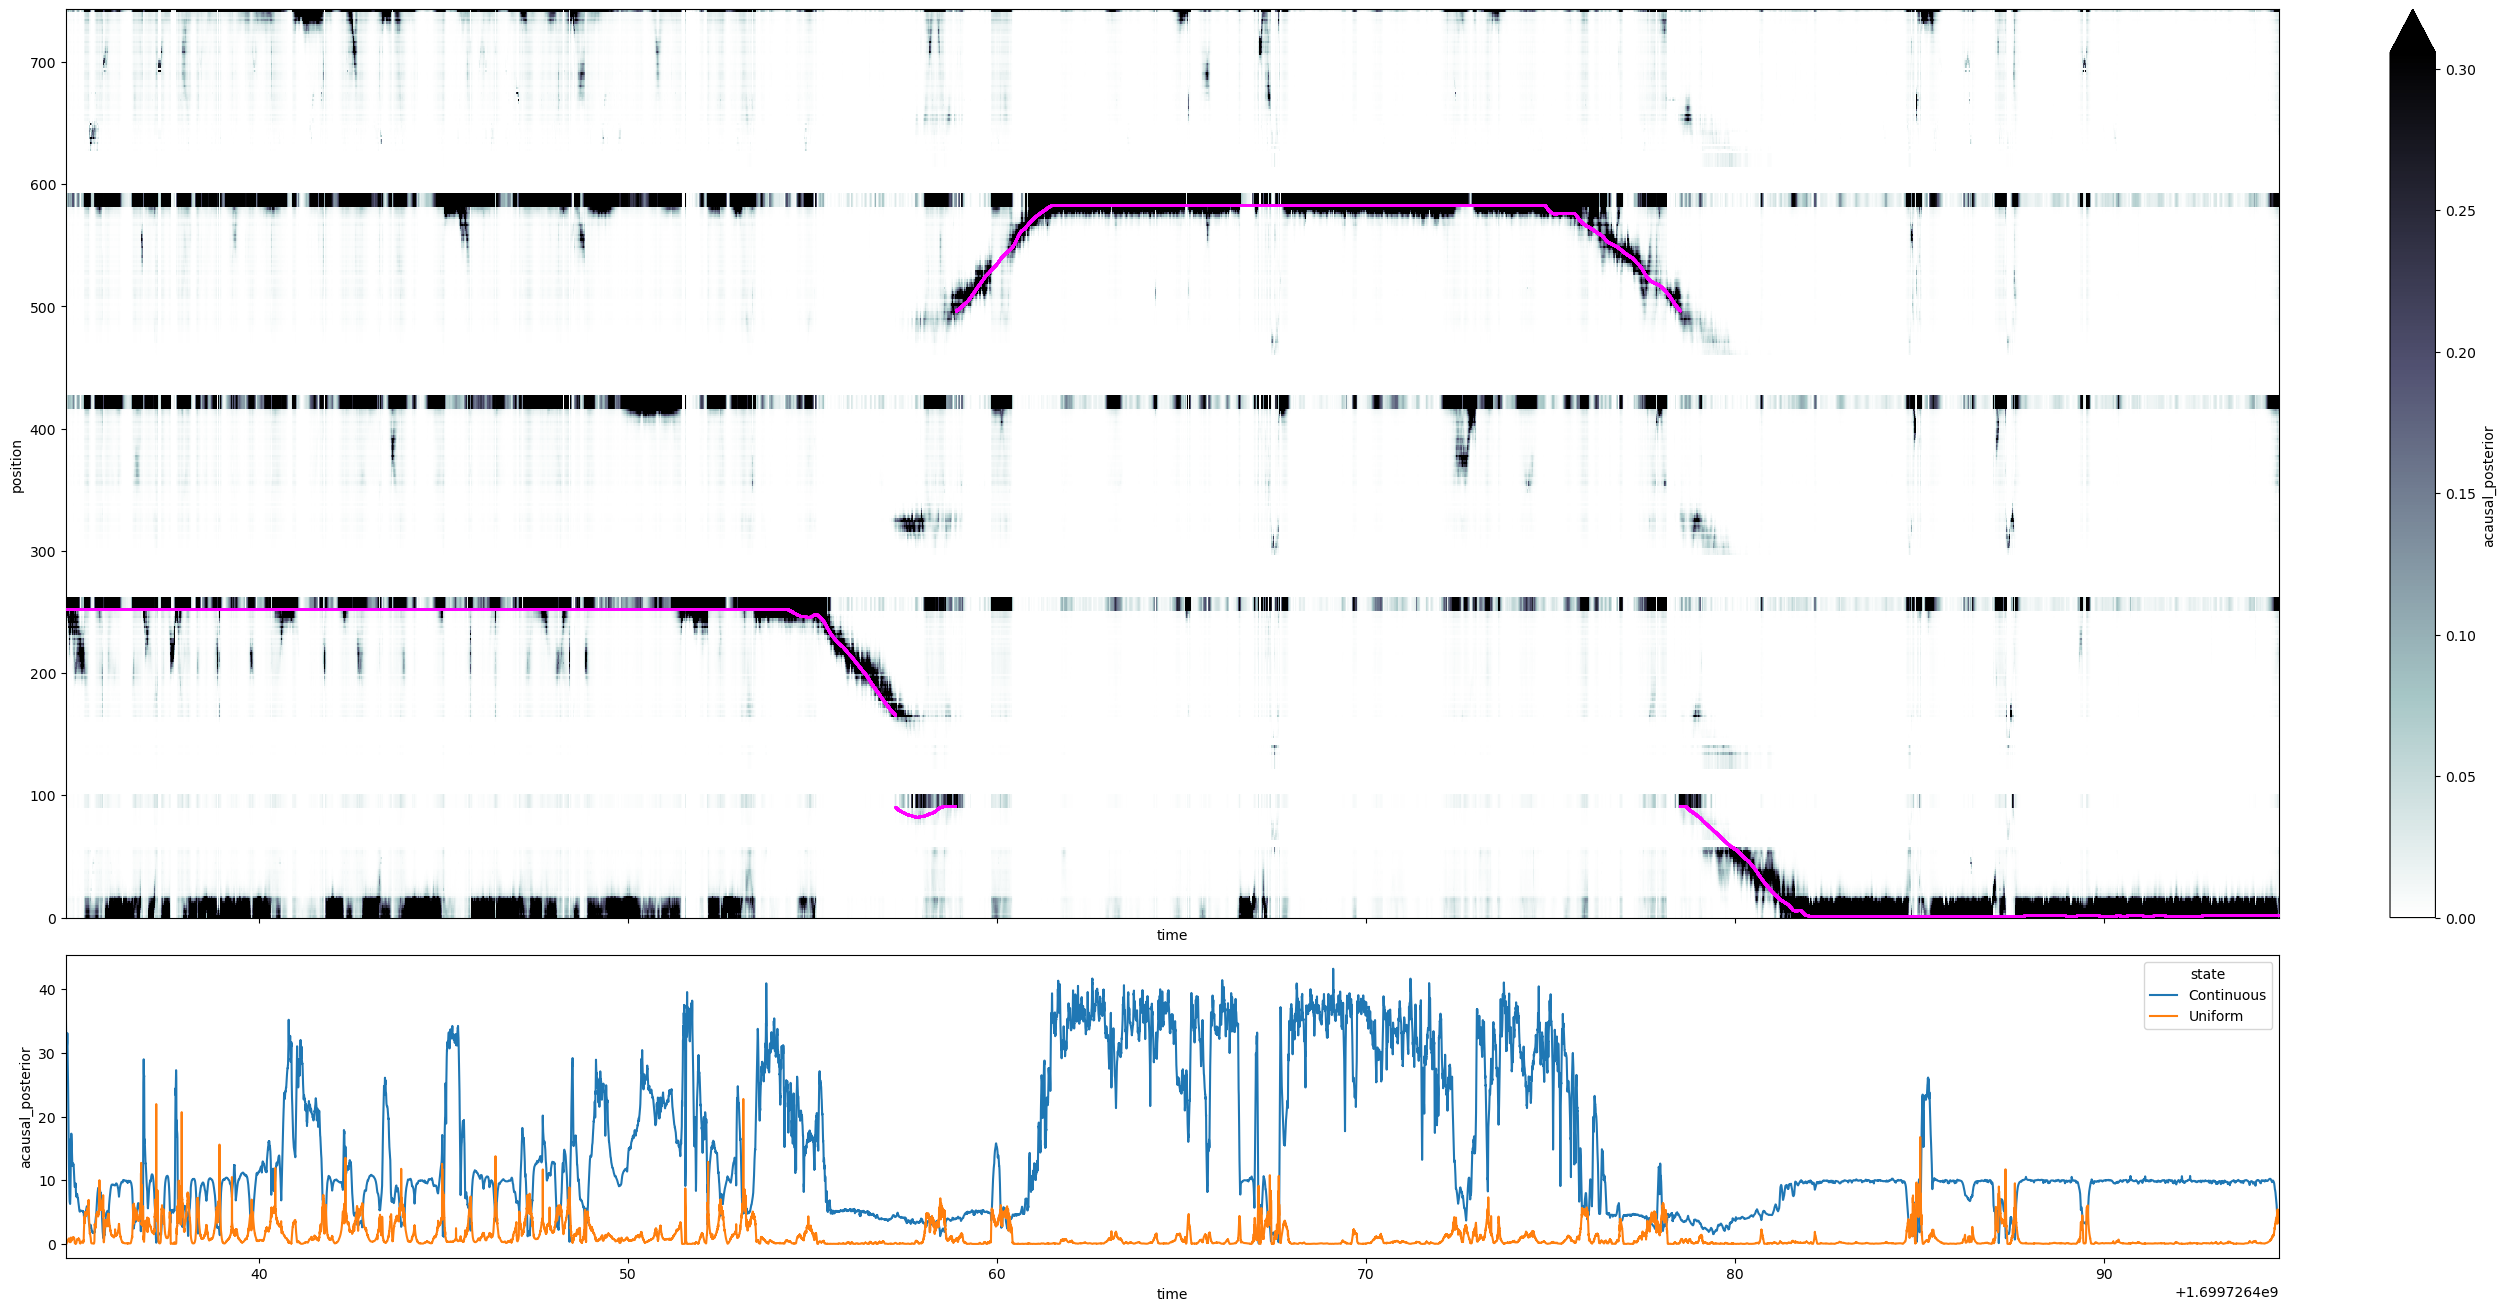

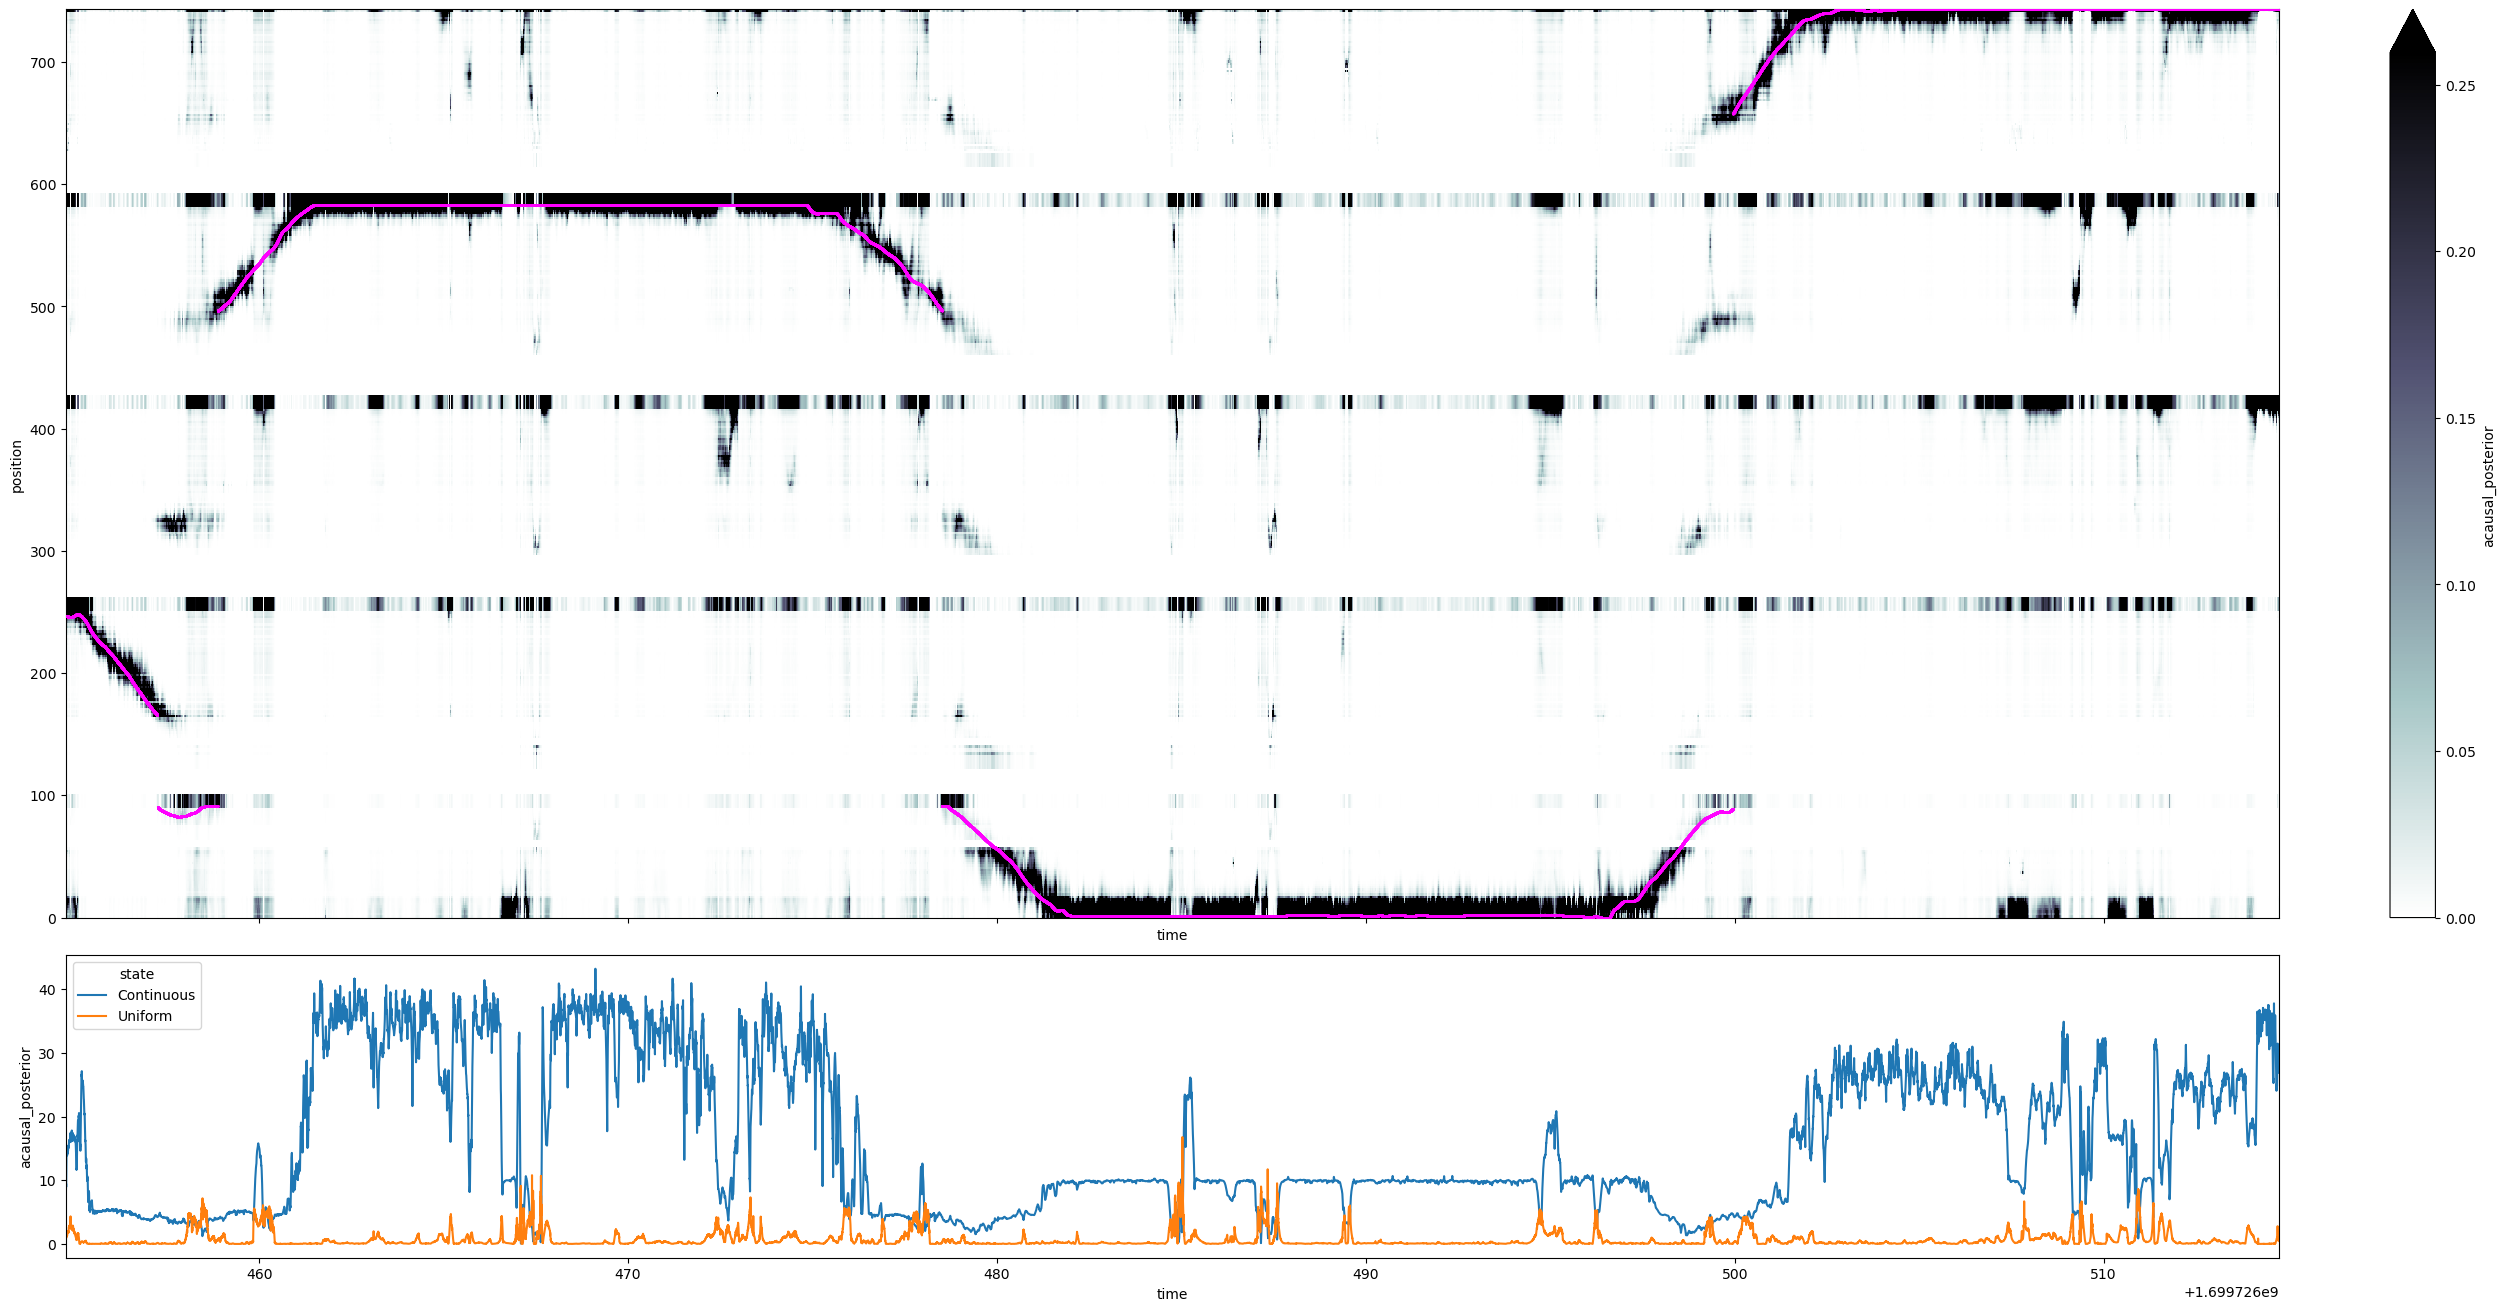

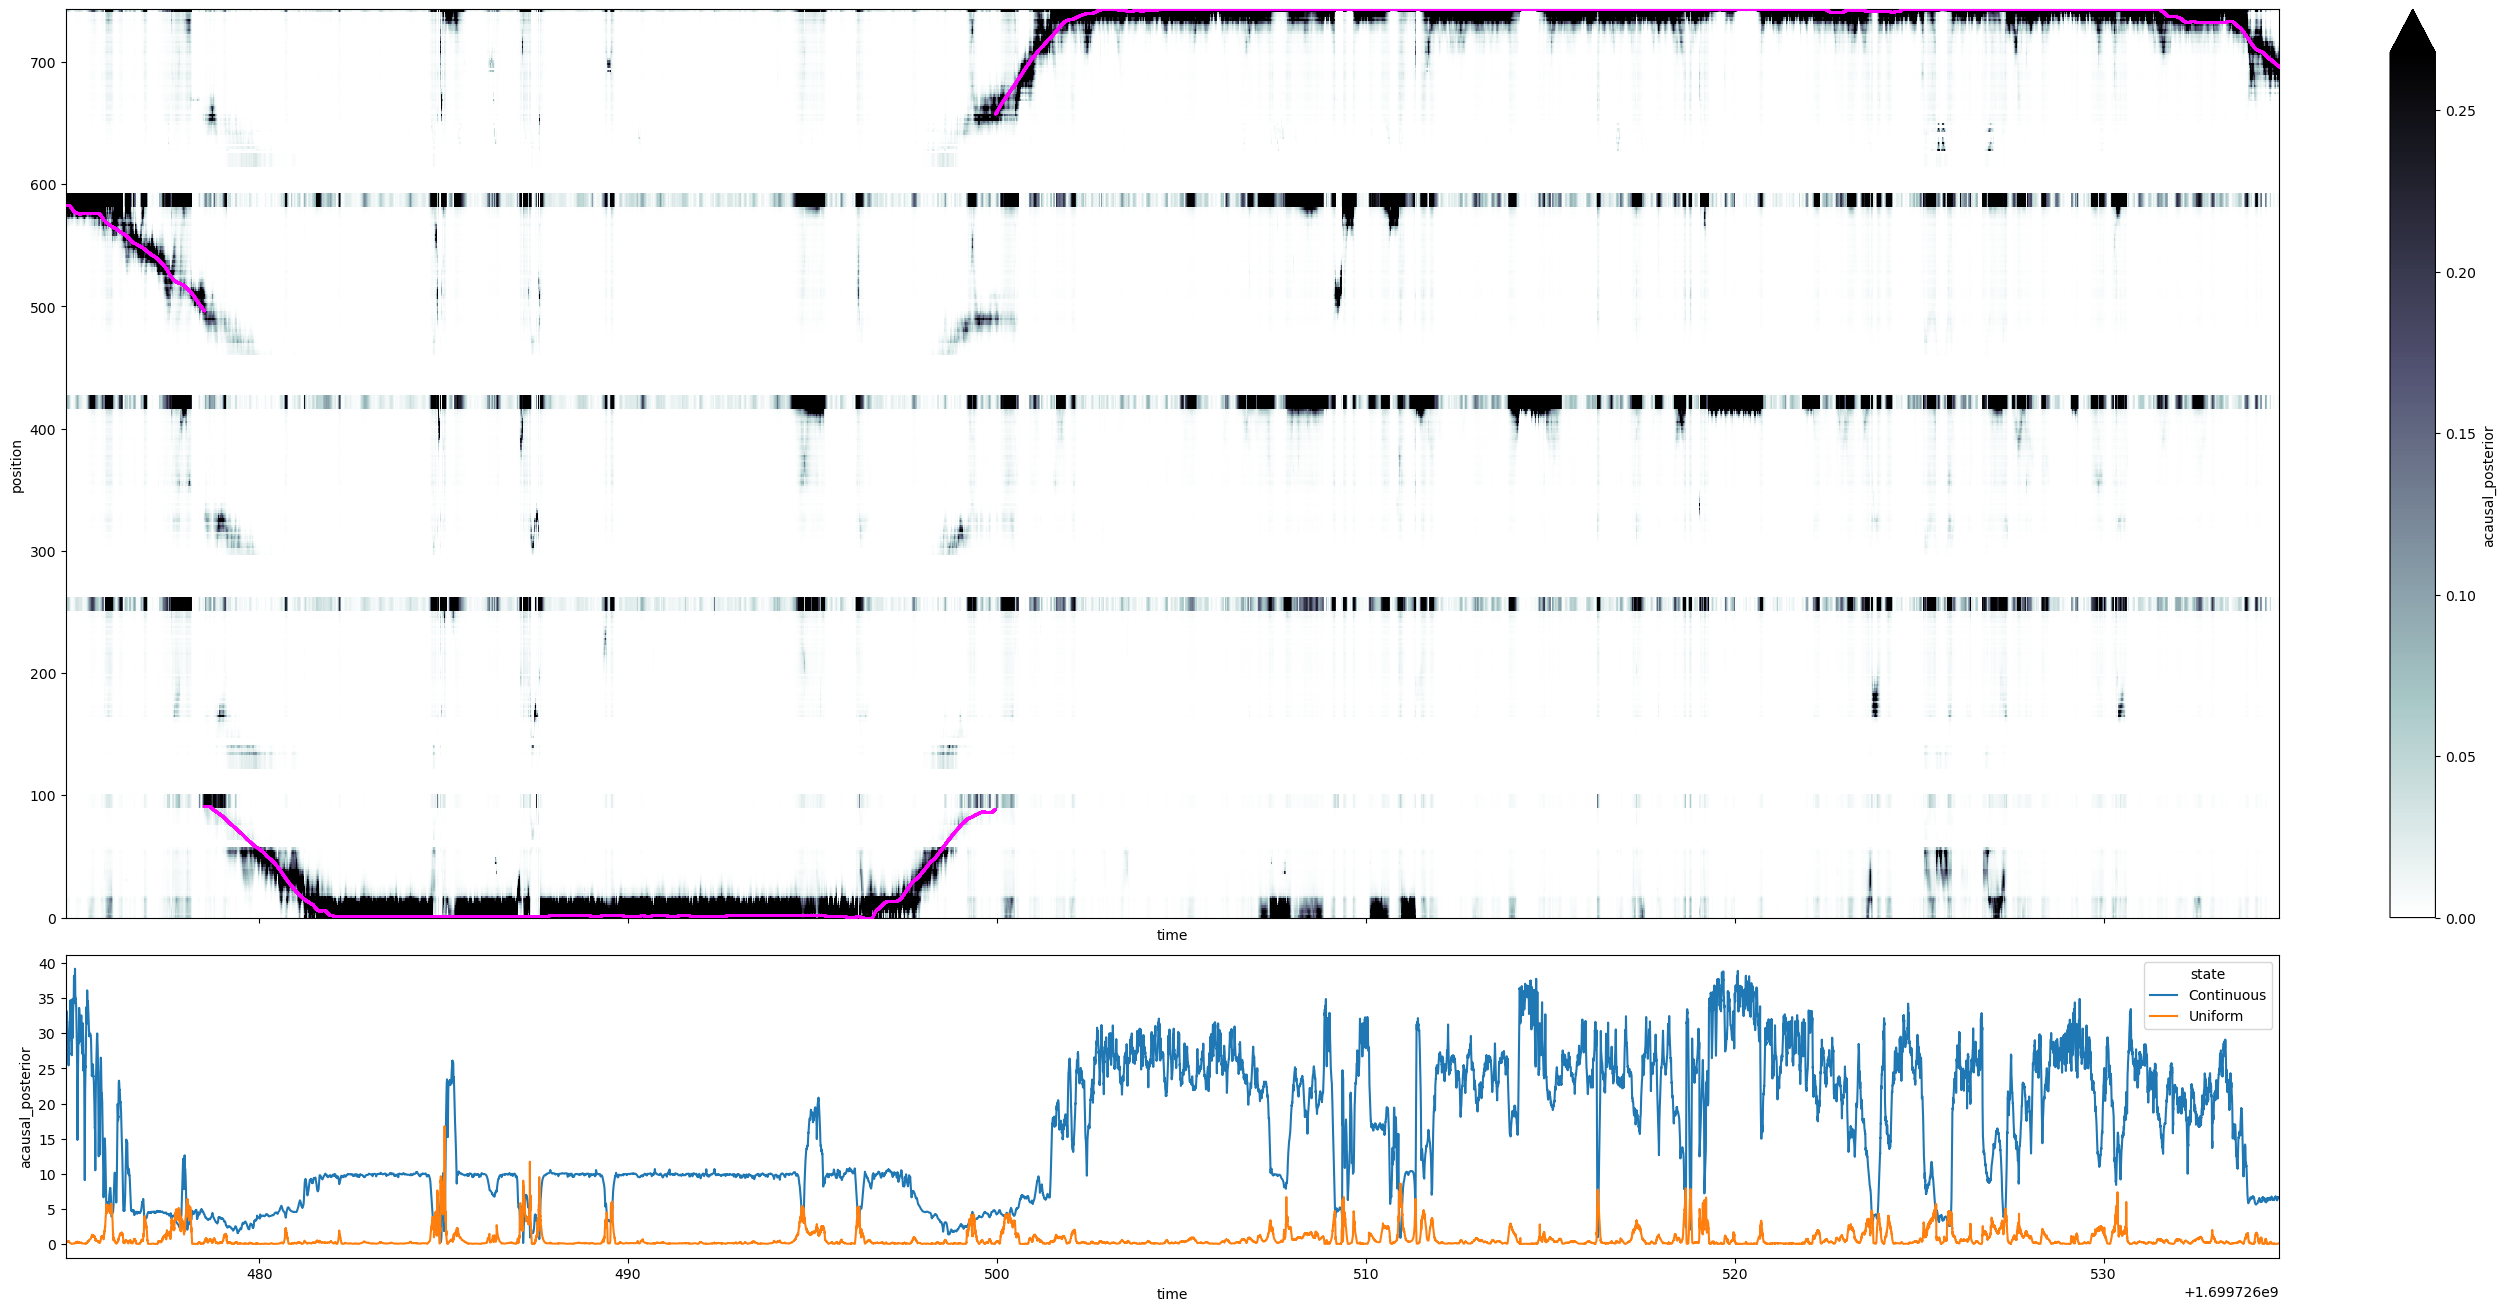

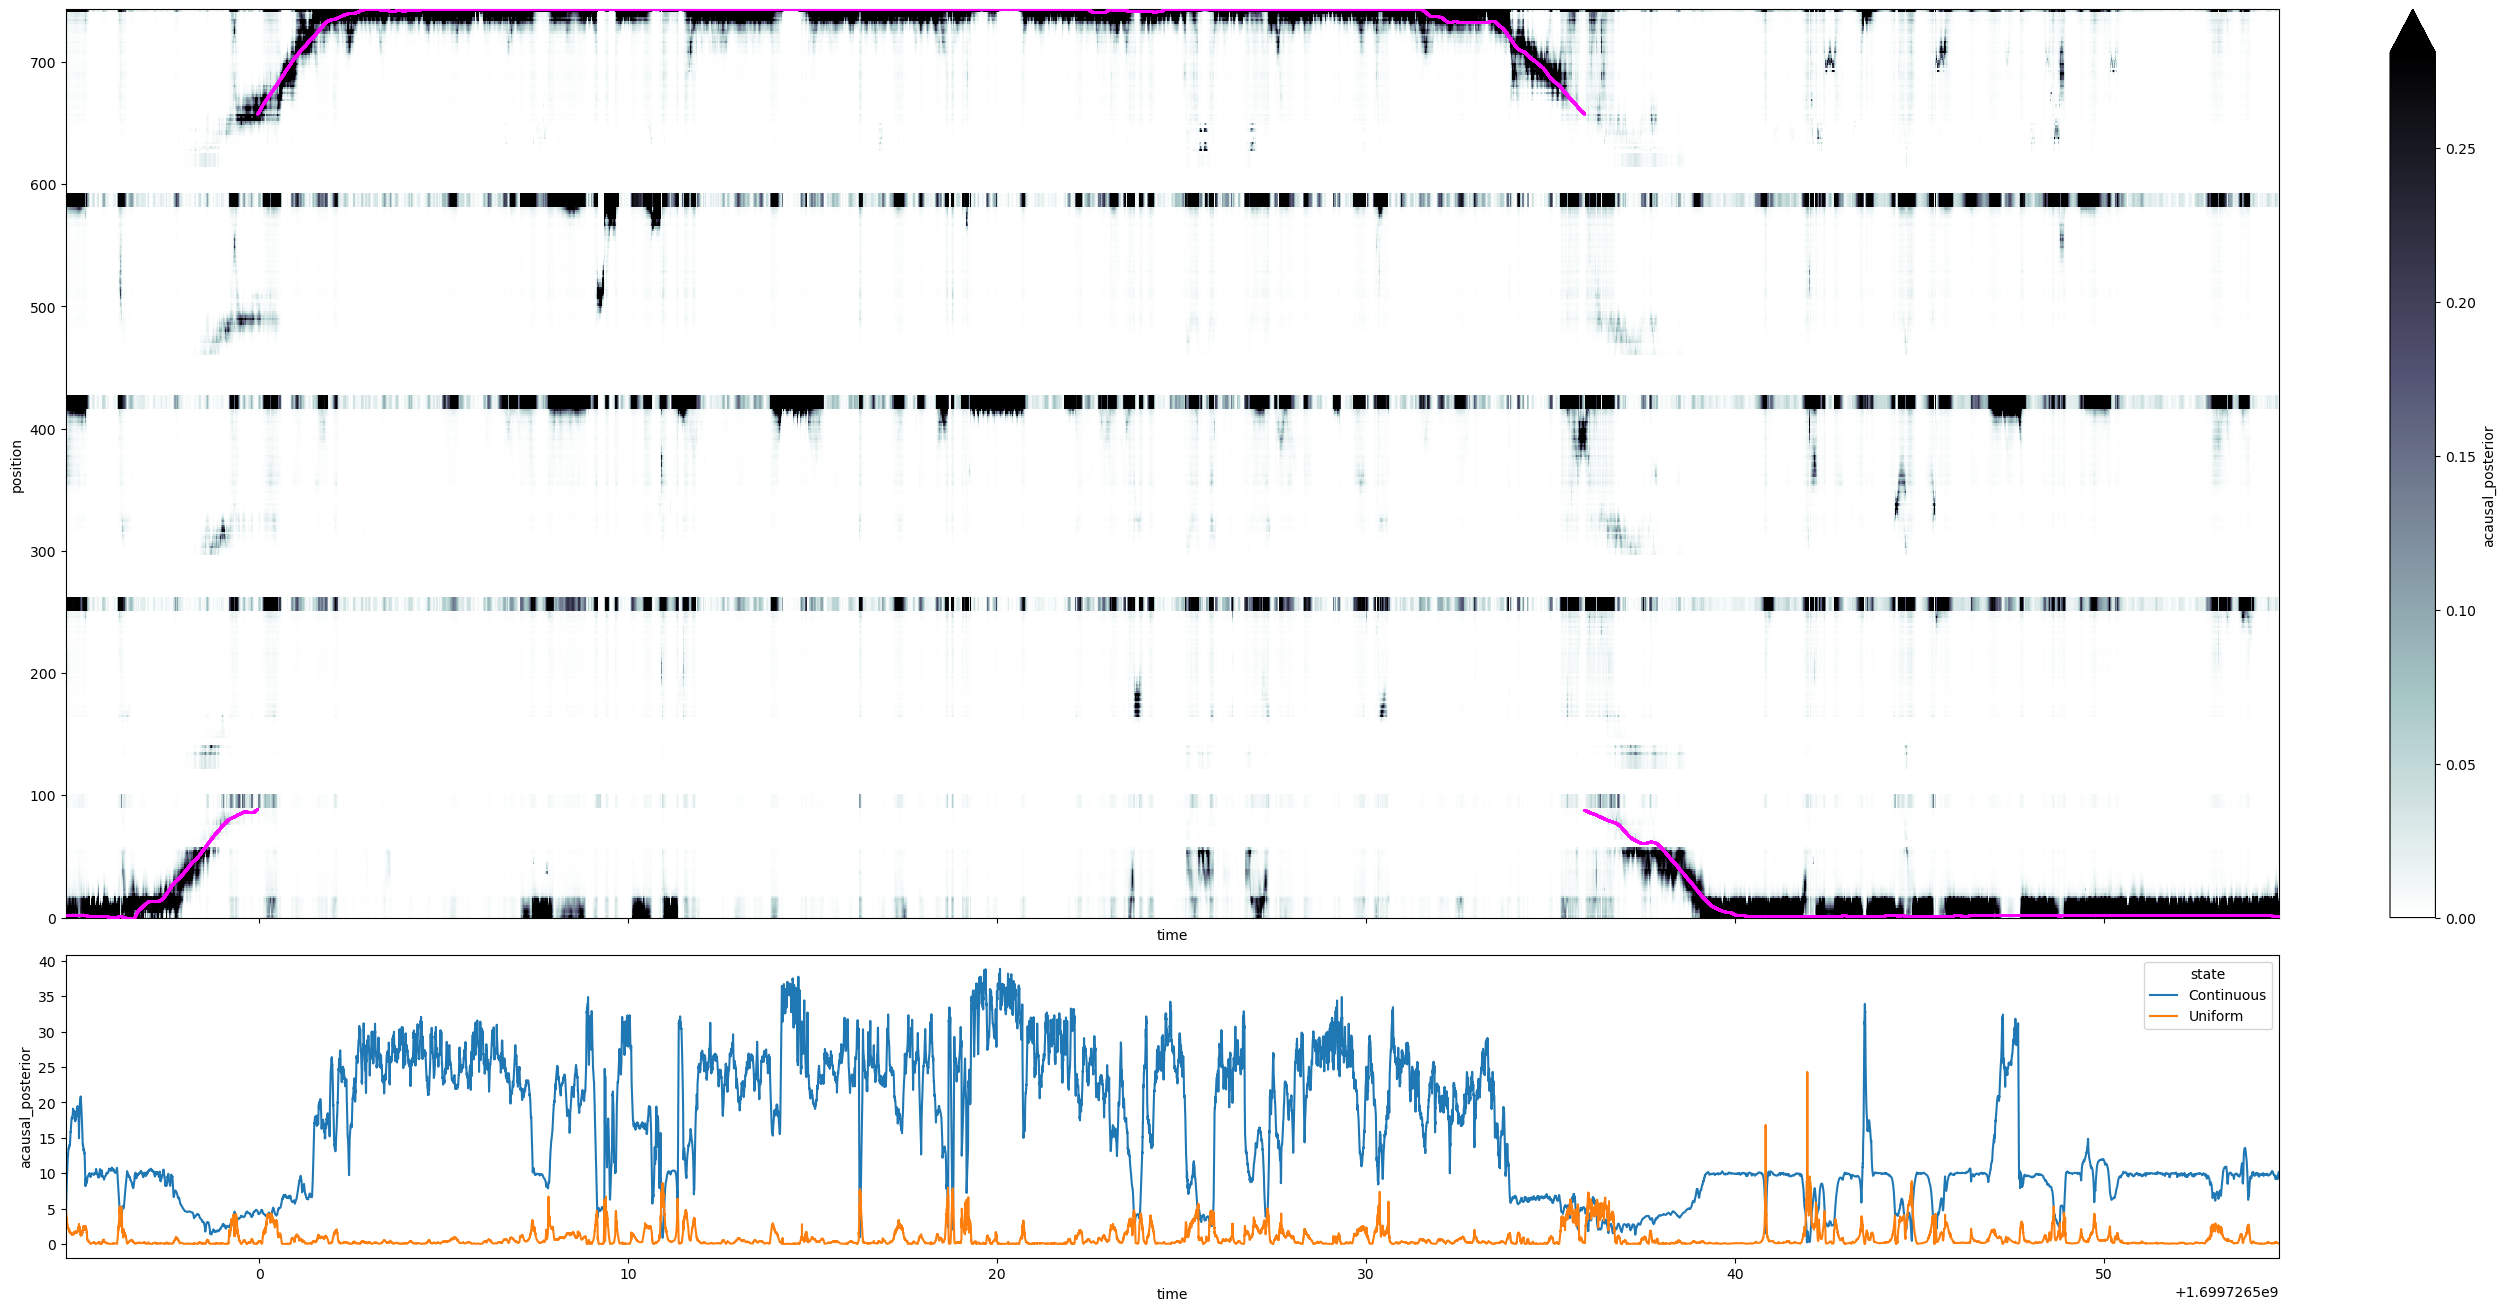

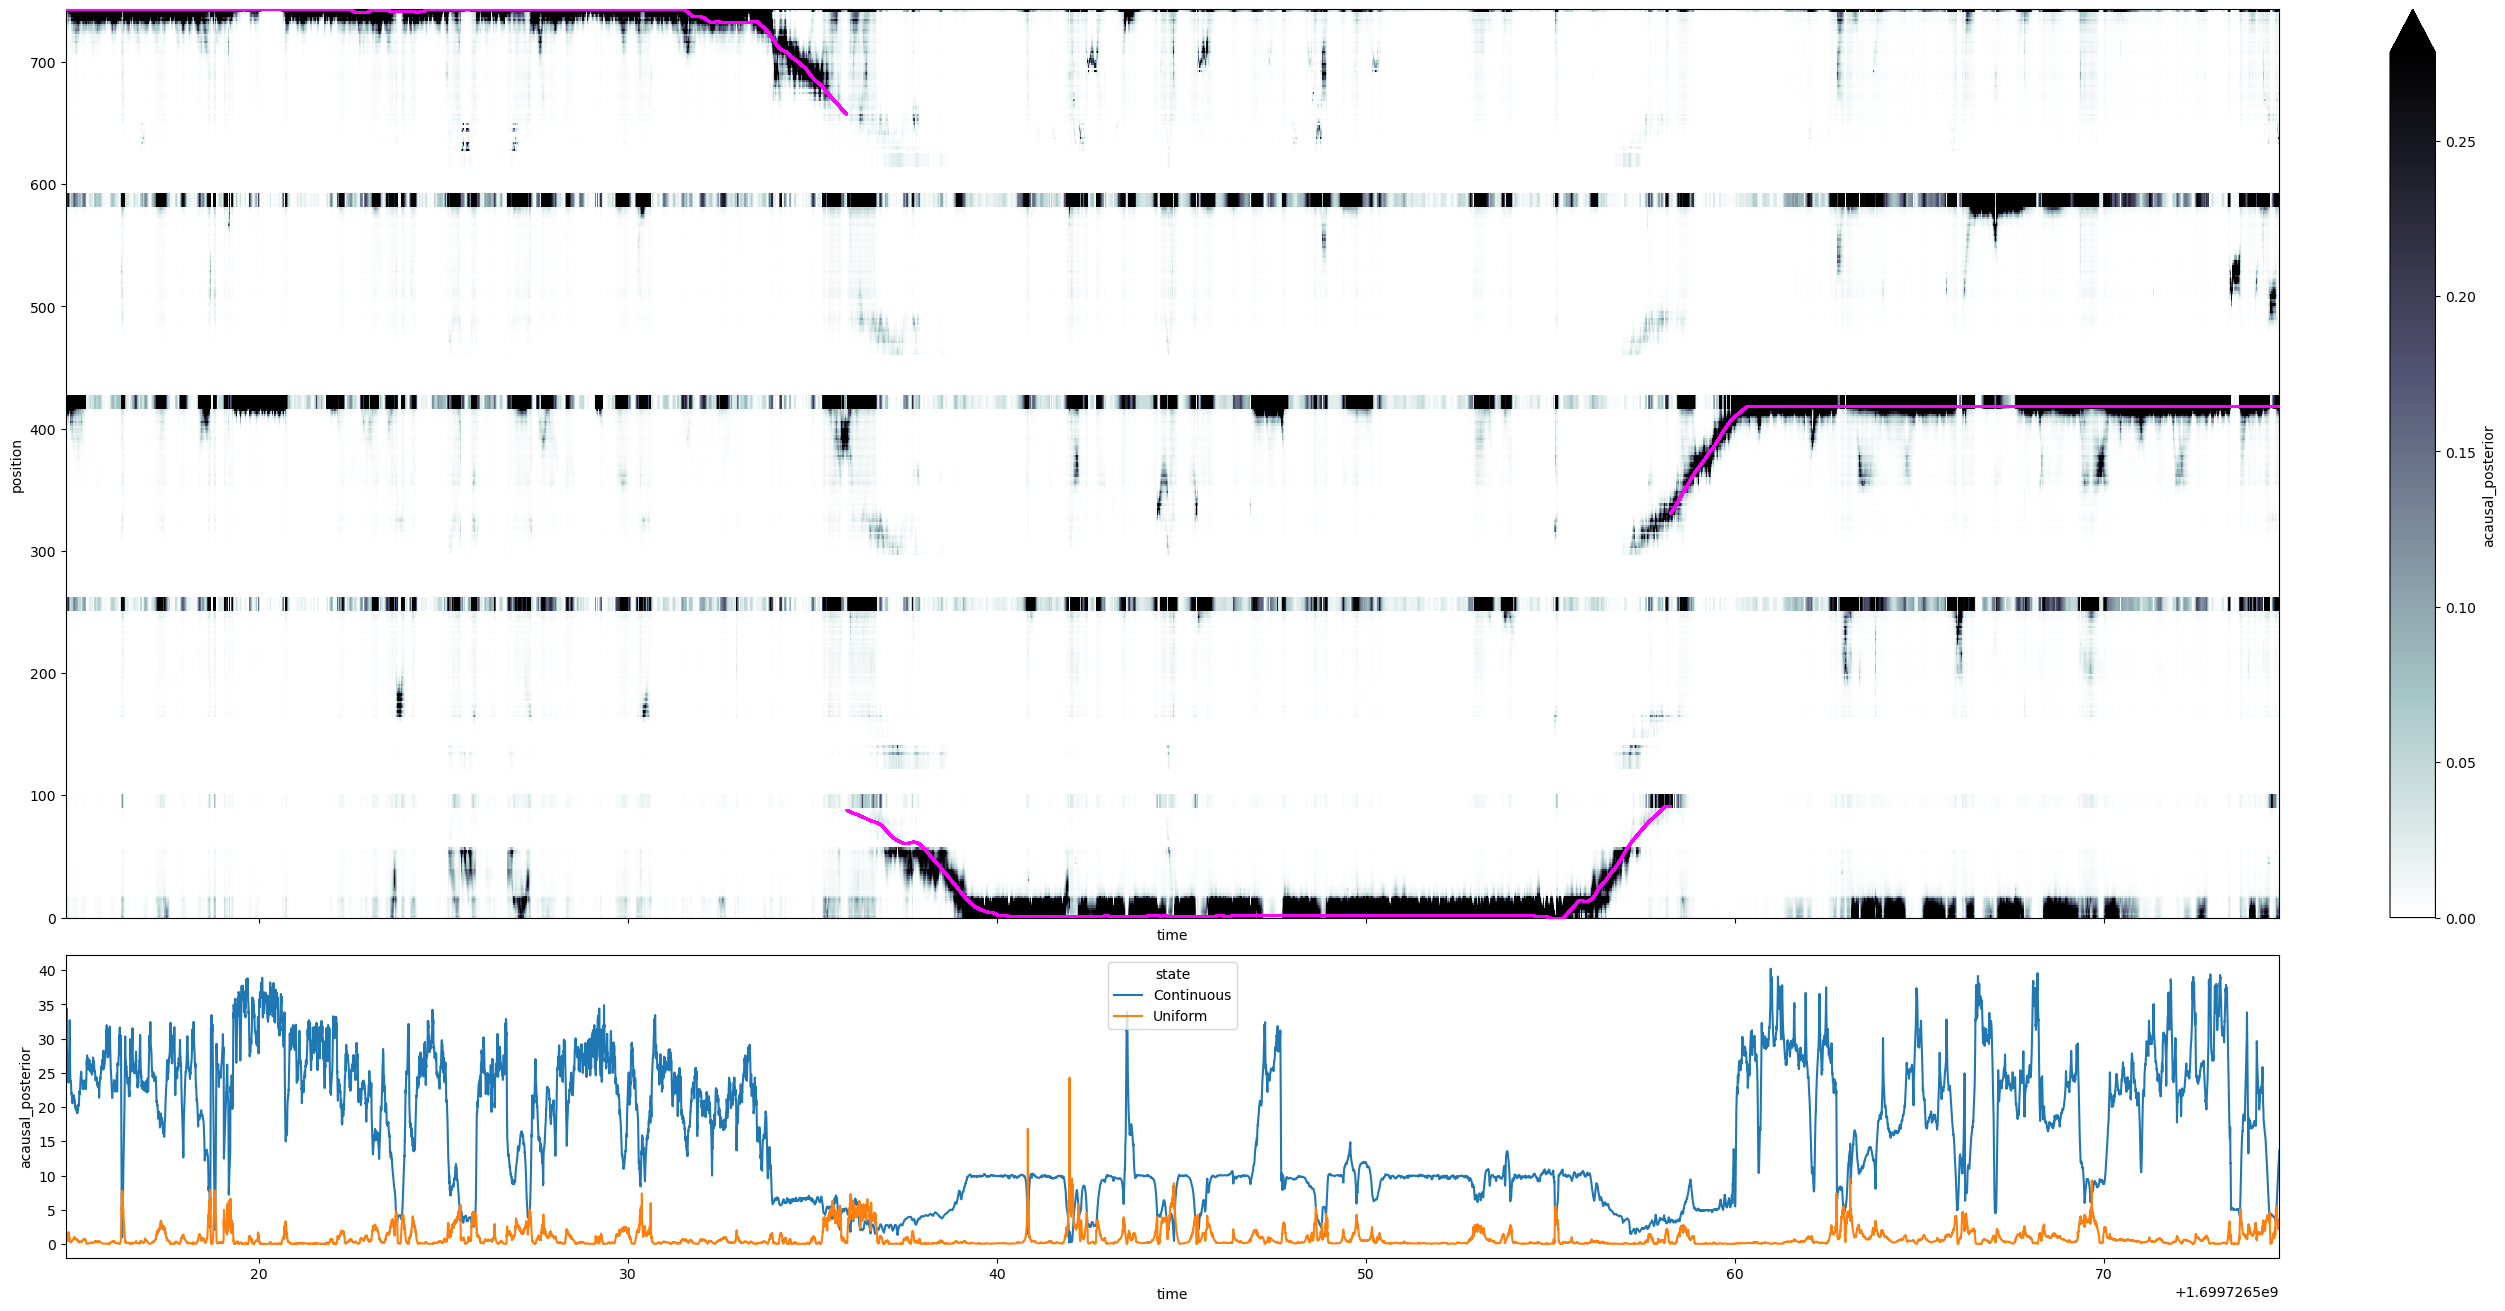

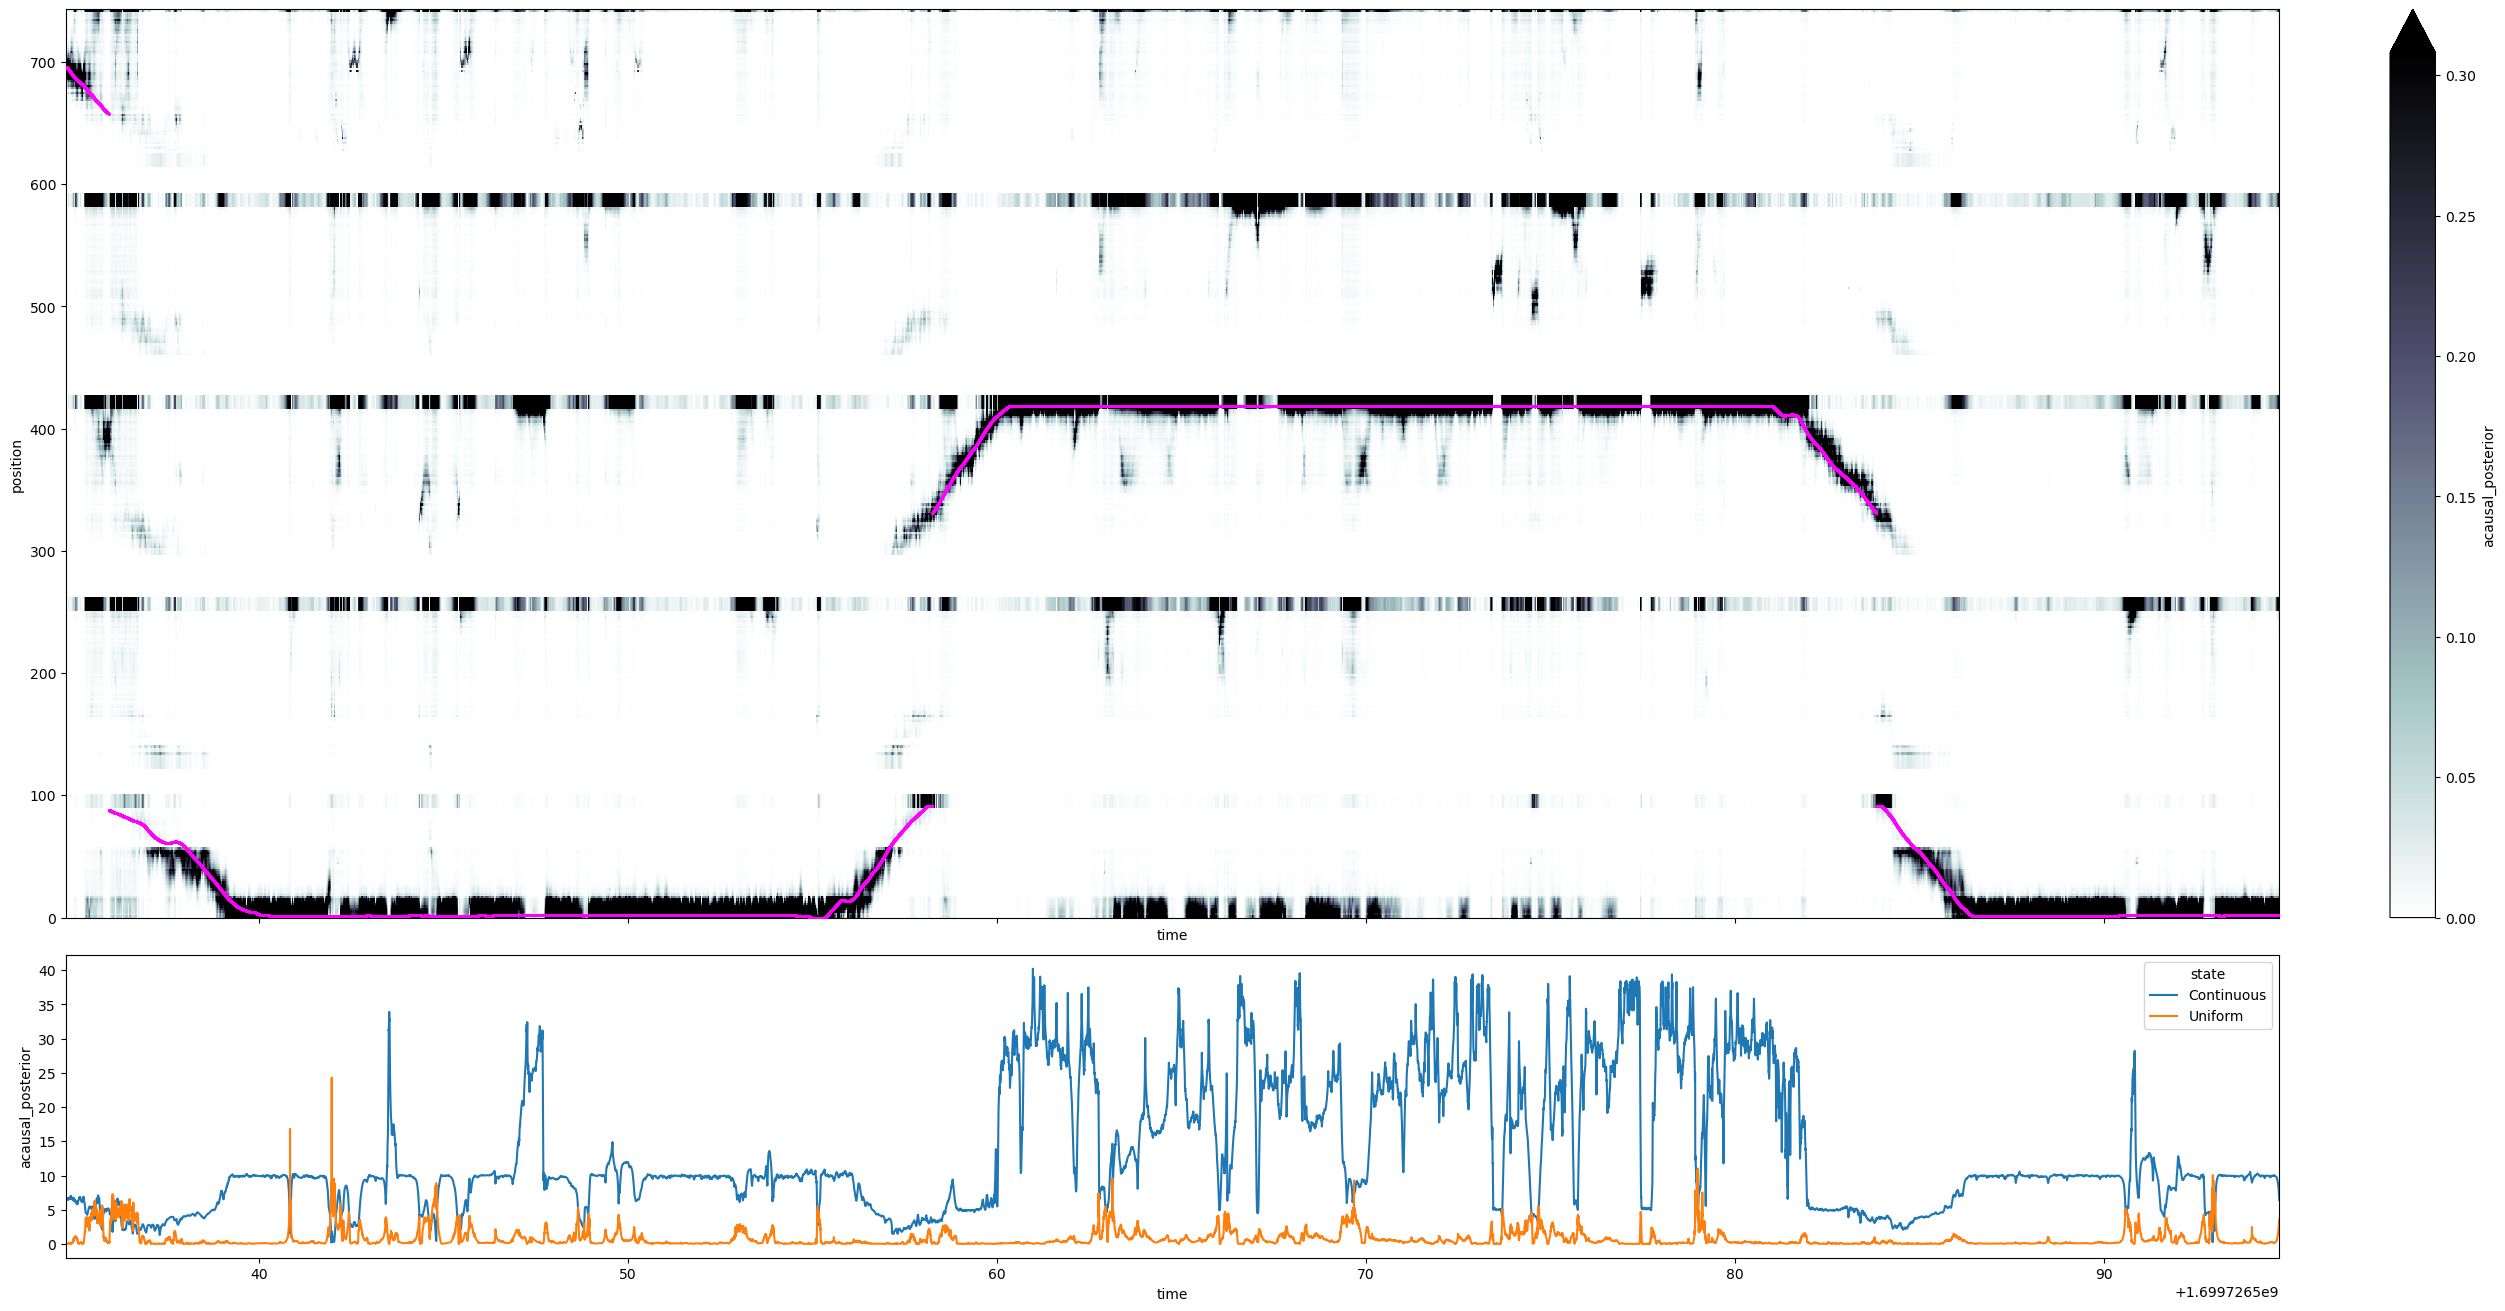

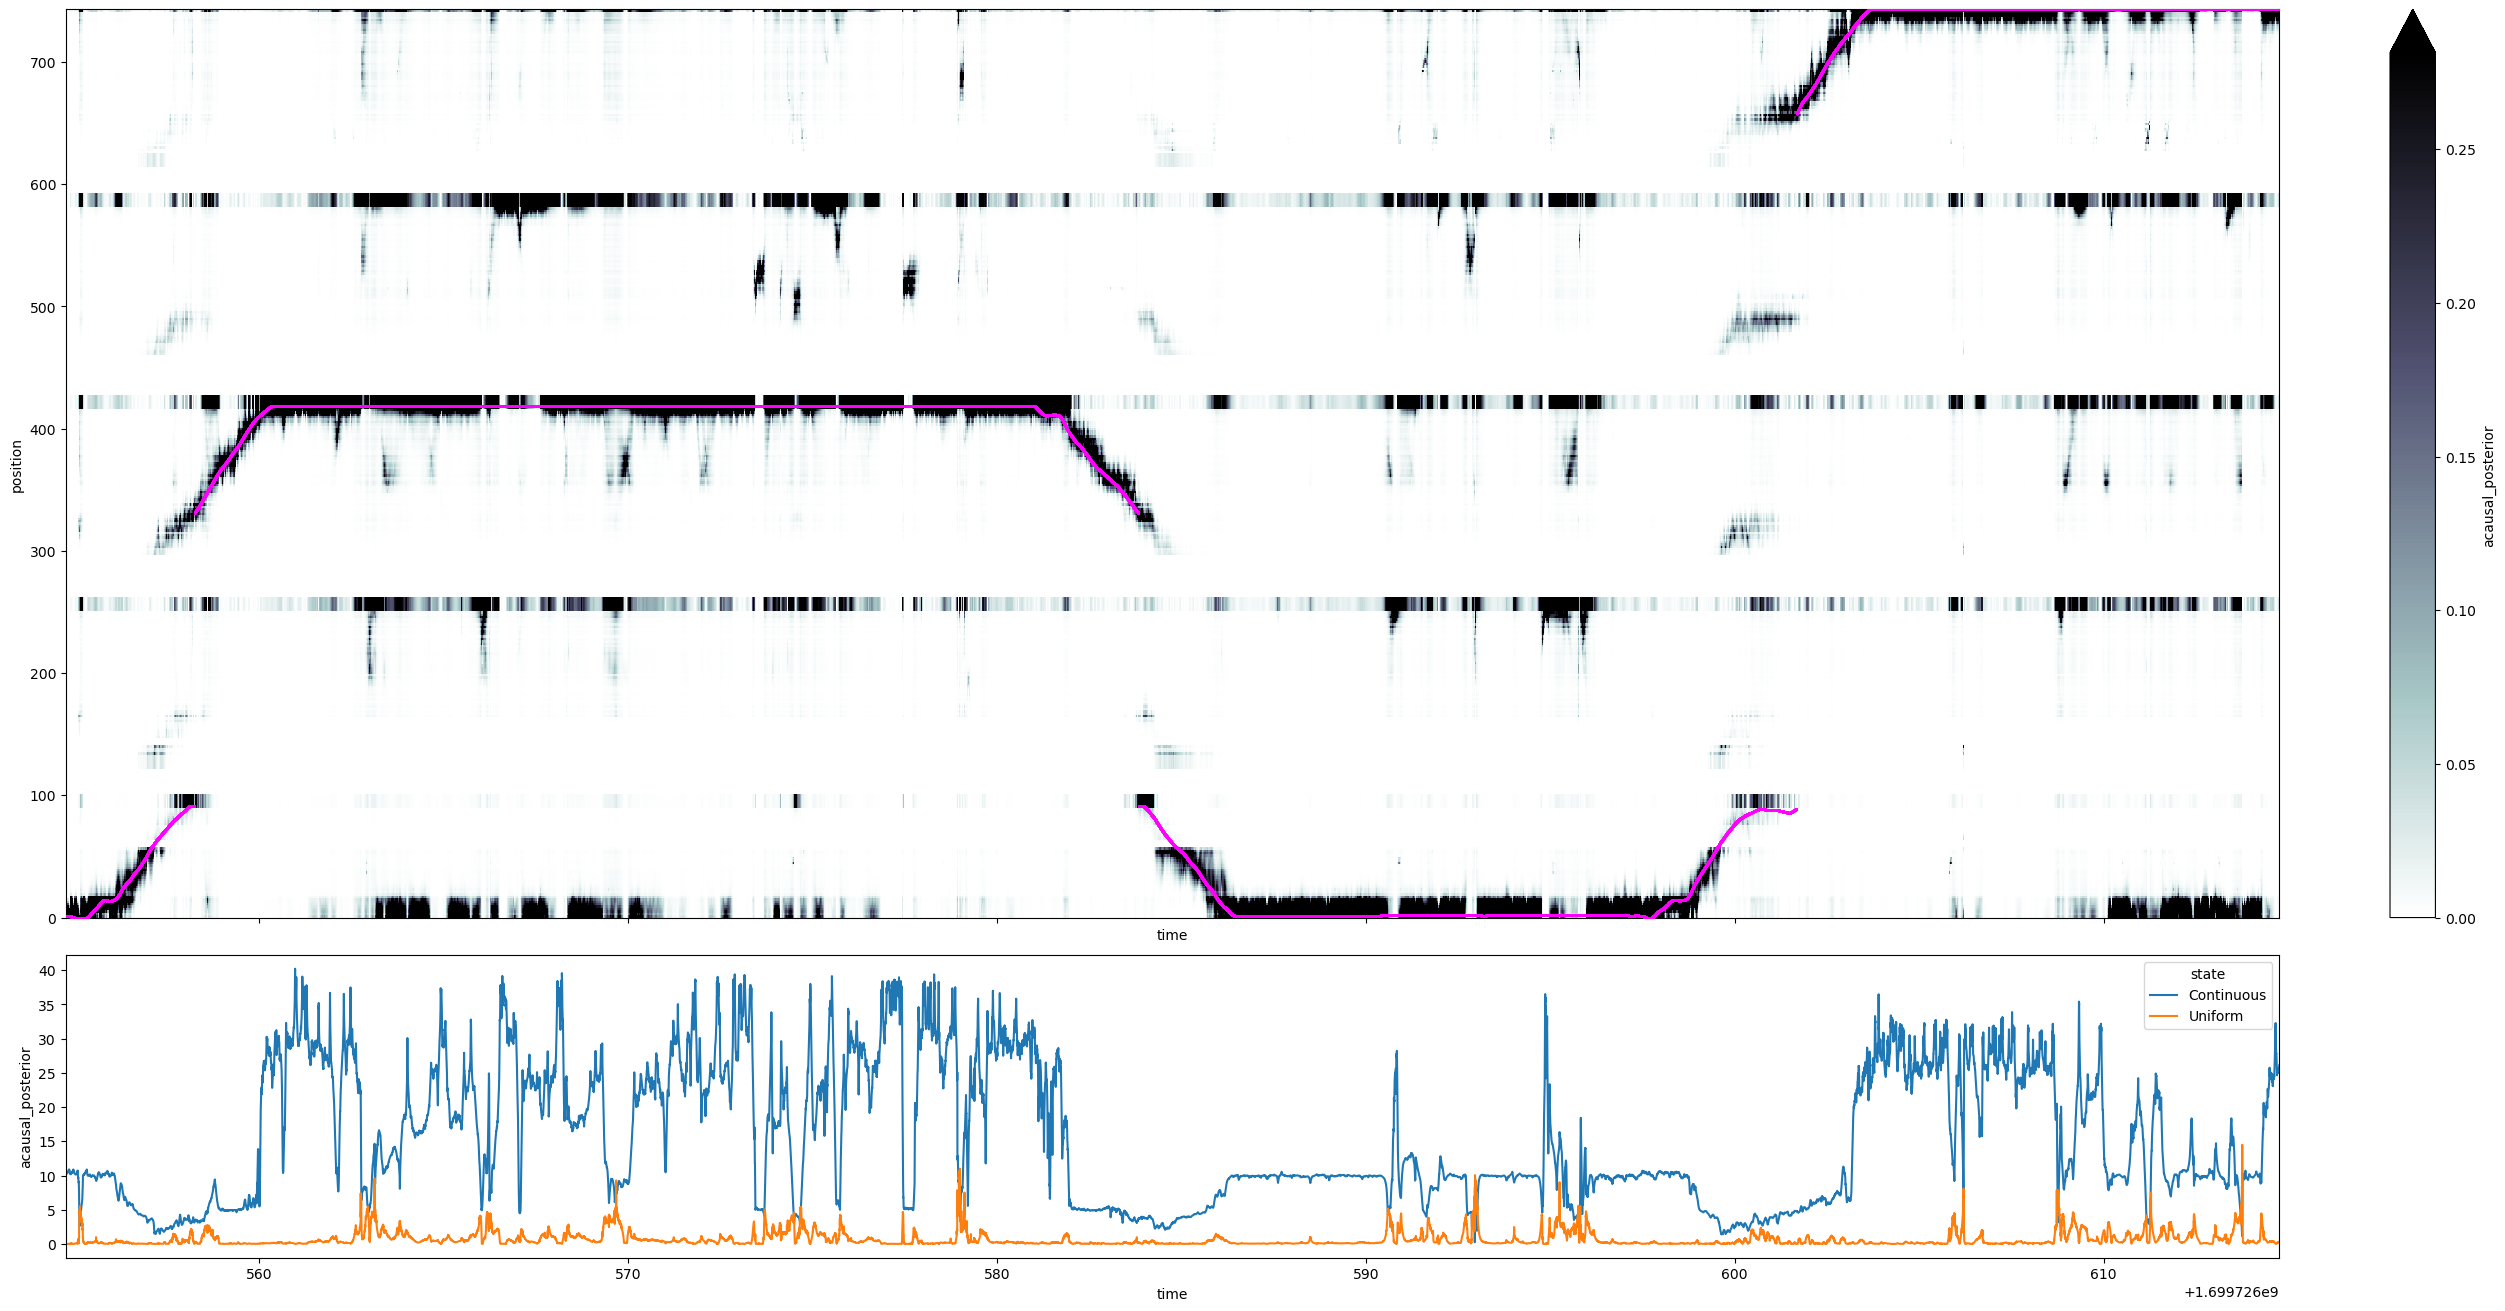

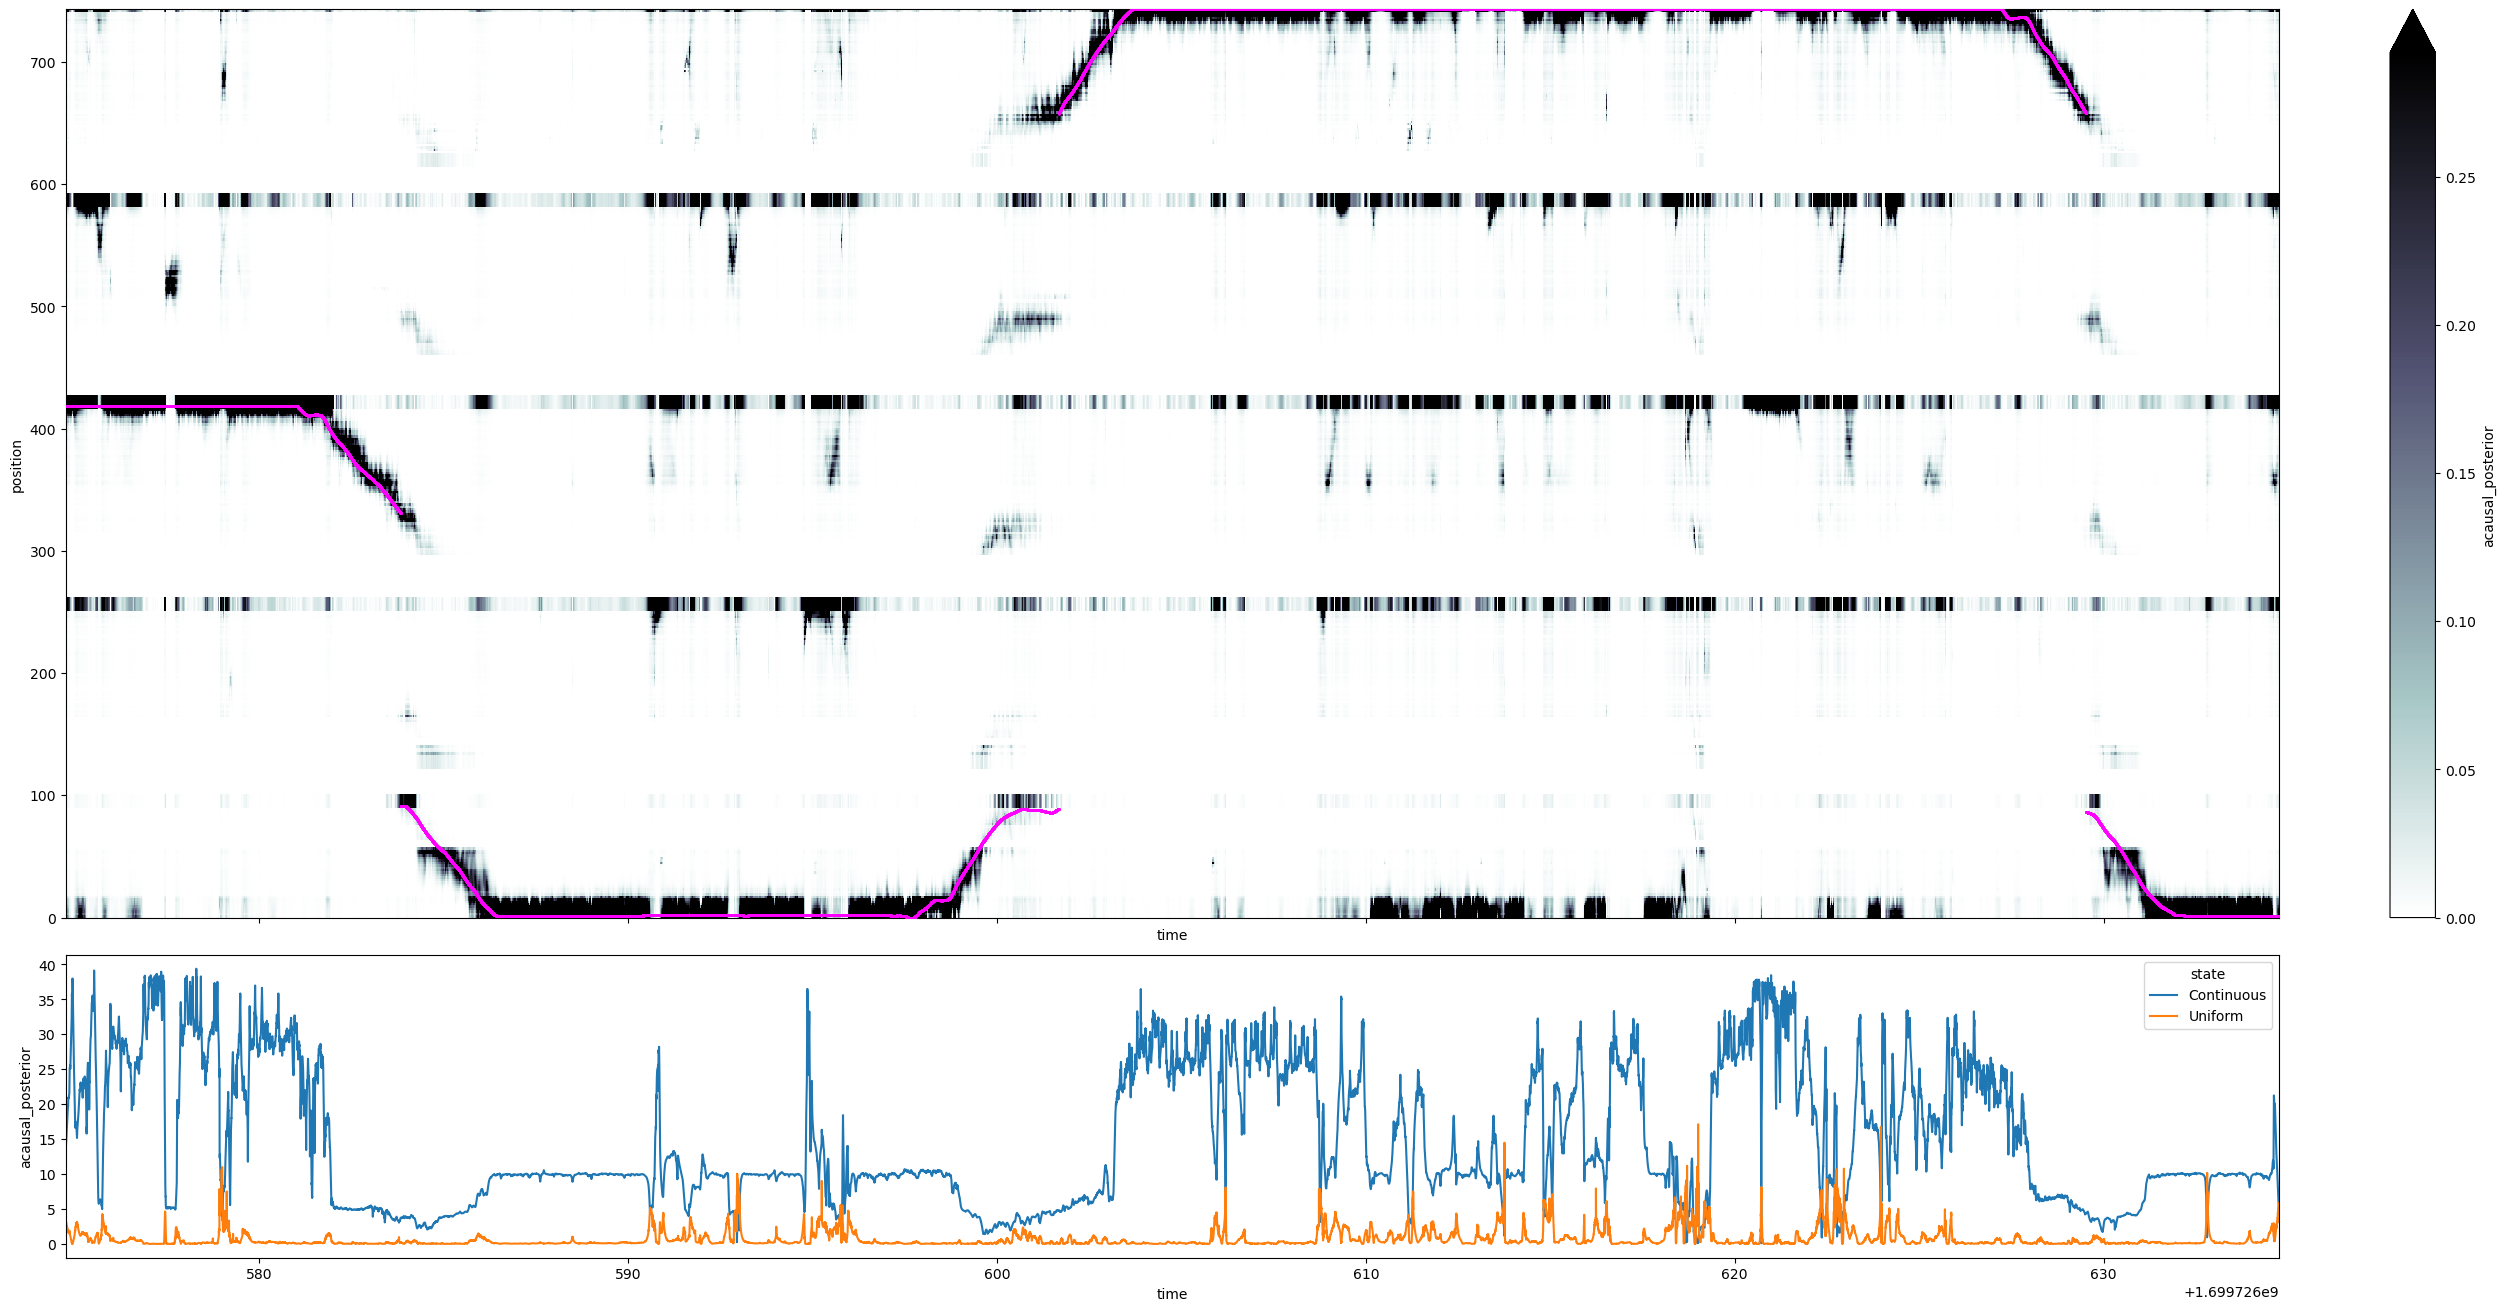

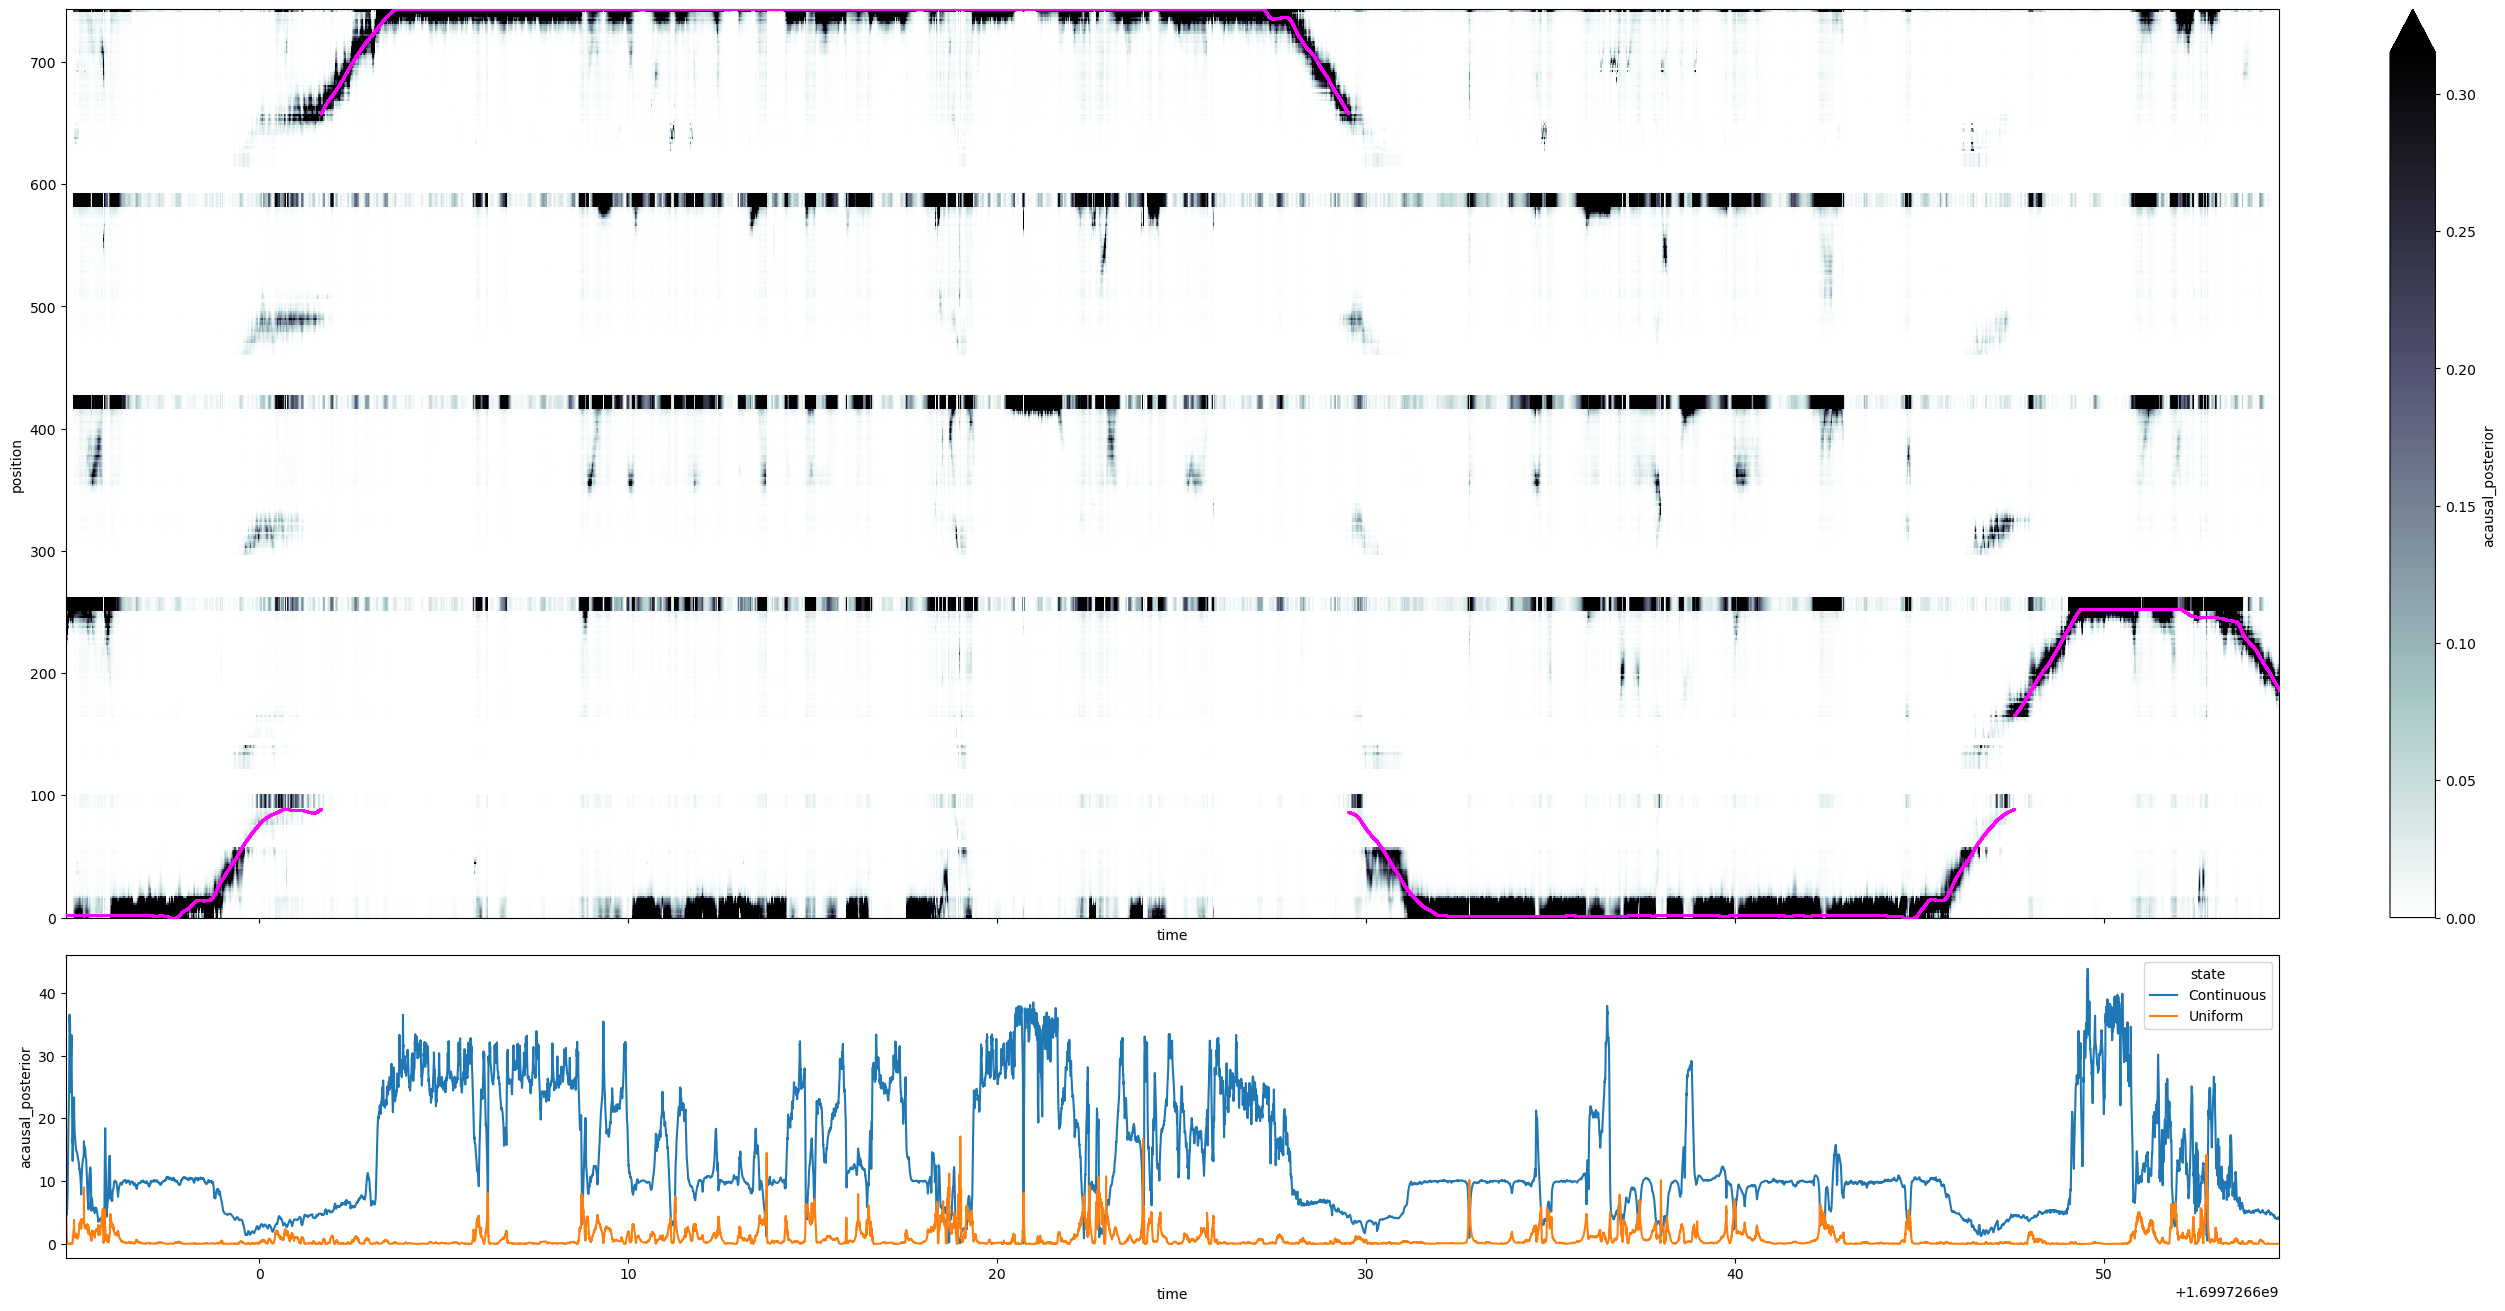

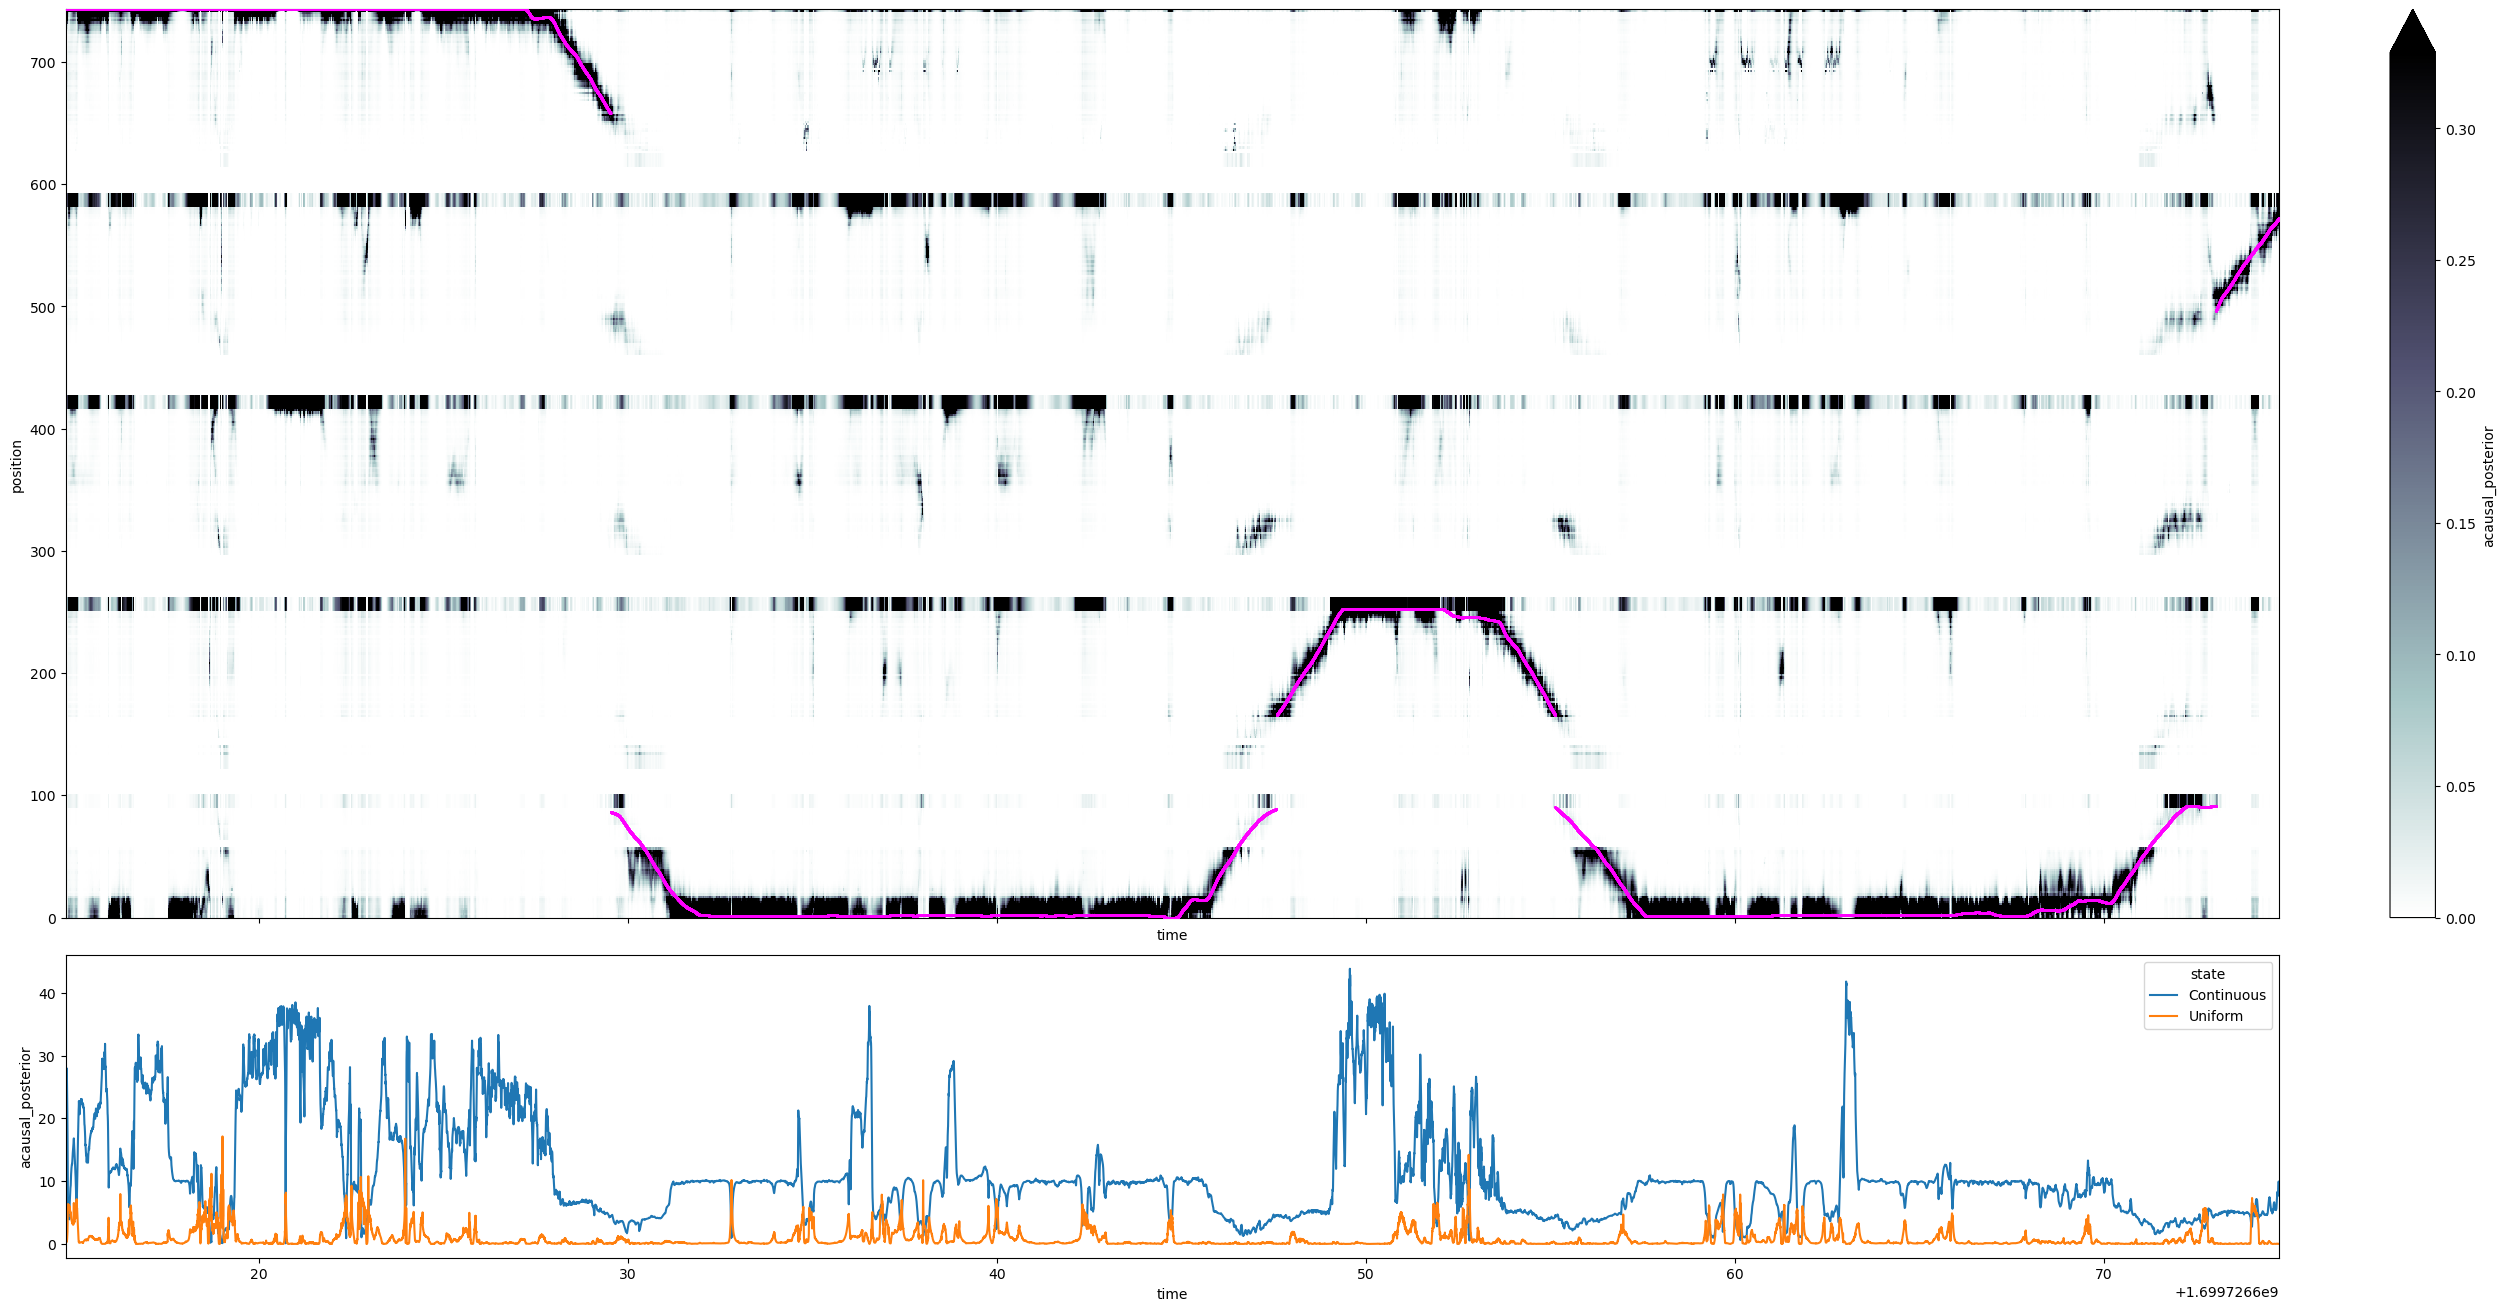

In [120]:
import matplotlib.pyplot as plt
for time_ind in range(0, 100_000, 10_000): #range(0, 600_000, 100_000)
    time_slice = slice(time_ind, time_ind + 30_000)

    fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)
    results1D.isel(time=time_slice).acausal_posterior.sum('state').plot(x='time', y='position',
                                                                      ax=axes[0], robust=True, cmap='bone_r',rasterized = True)
    axes[0].scatter(position_1d.iloc[time_slice].time,
                    position_1d.iloc[time_slice].linear_position.values,
                    s=1, color='magenta', zorder=10)
 
    results1D.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])

In [ ]:
import matplotlib.pyplot as plt

time_slice = slice(100_050, 110_000)

fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)

results.isel(time=time_slice).acausal_posterior.sum('state').plot(x='time', y='position', ax=axes[0], robust=True, cmap='bone_r')
axes[0].scatter(position_1d.iloc[time_slice].time,
                position_1d.iloc[time_slice].linear_position.values,
                s=1, color='magenta', zorder=10)

results.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])

In [ ]:
results.time[1] - results.time[0]

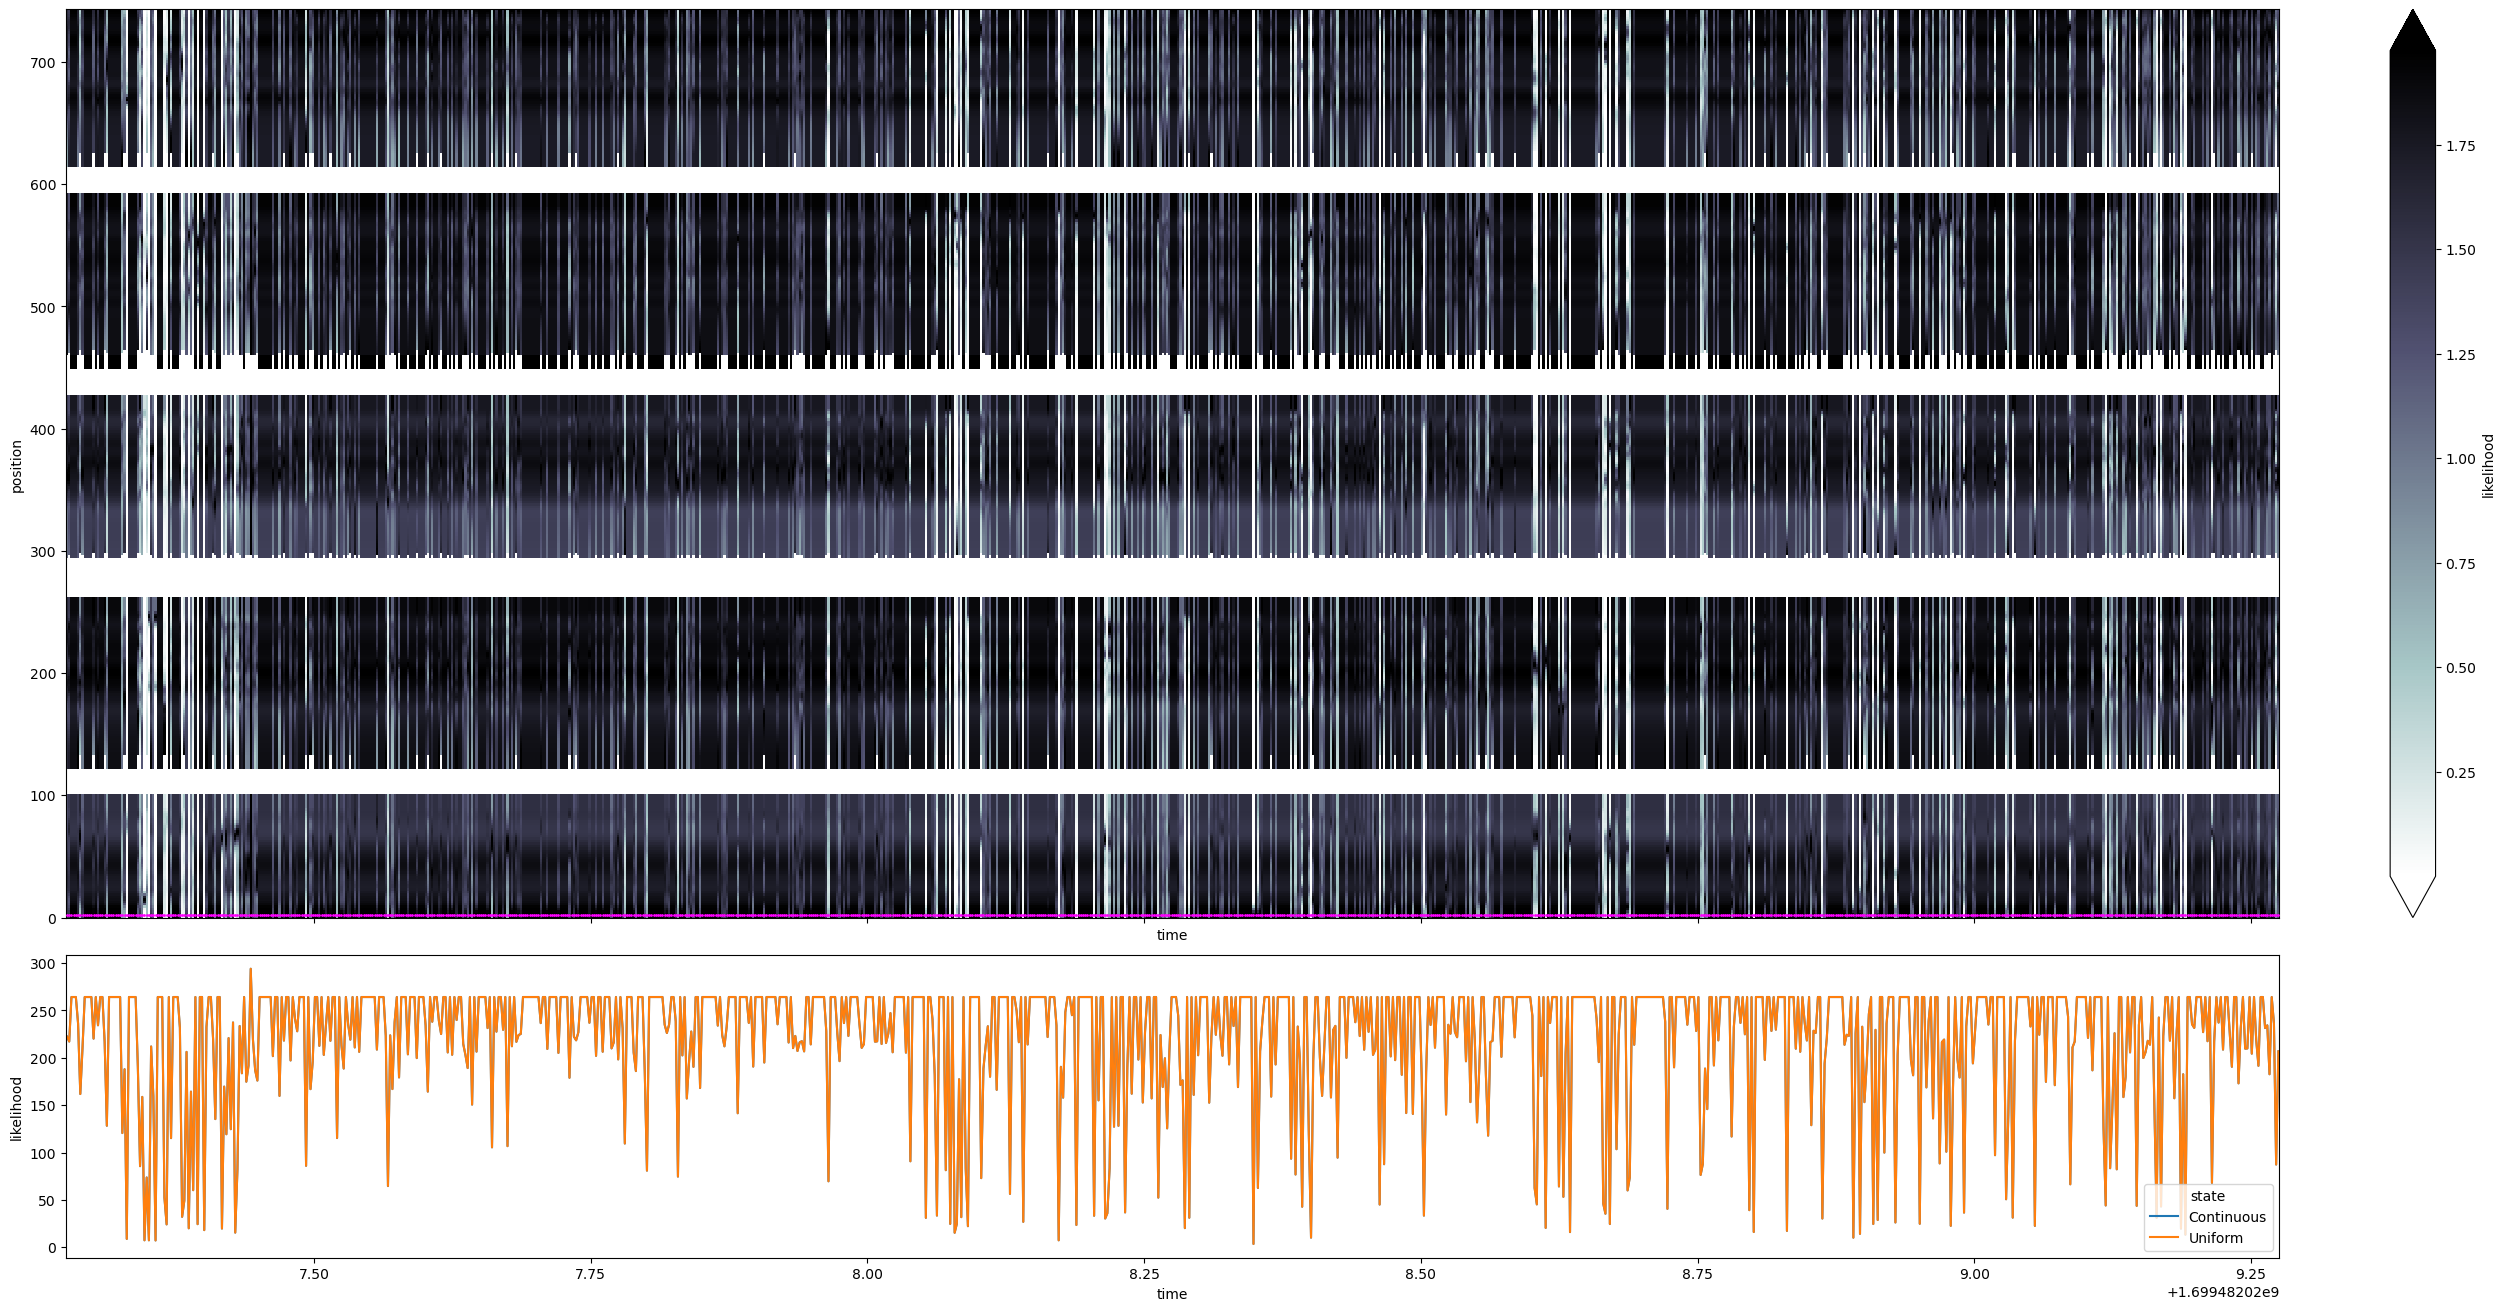

In [199]:
import matplotlib.pyplot as plt

time_slice = slice(102_000, 102_000 + 1000)

fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)

results.isel(time=time_slice).likelihood.sum('state').plot(x='time', y='position', ax=axes[0], robust=True, cmap='bone_r')
axes[0].scatter(position_1d.iloc[time_slice].time,
                position_1d.iloc[time_slice].linear_position.values,
                s=1, color='magenta', zorder=10)

results.isel(time=time_slice).likelihood.sum('position').plot(x='time', hue='state', ax=axes[1])

In [ ]:
import matplotlib.pyplot as plt

time_slice = slice(180_000, 190_000)

fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)

results.isel(time=time_slice).acausal_posterior.sum('state').plot(x='time', y='position', ax=axes[0], robust=True, cmap='bone_r')
axes[0].scatter(position_1d.iloc[time_slice].time,
                position_1d.iloc[time_slice].linear_position.values,
                s=1, color='magenta', zorder=10)

results.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])

TypeError: No numeric data to plot.

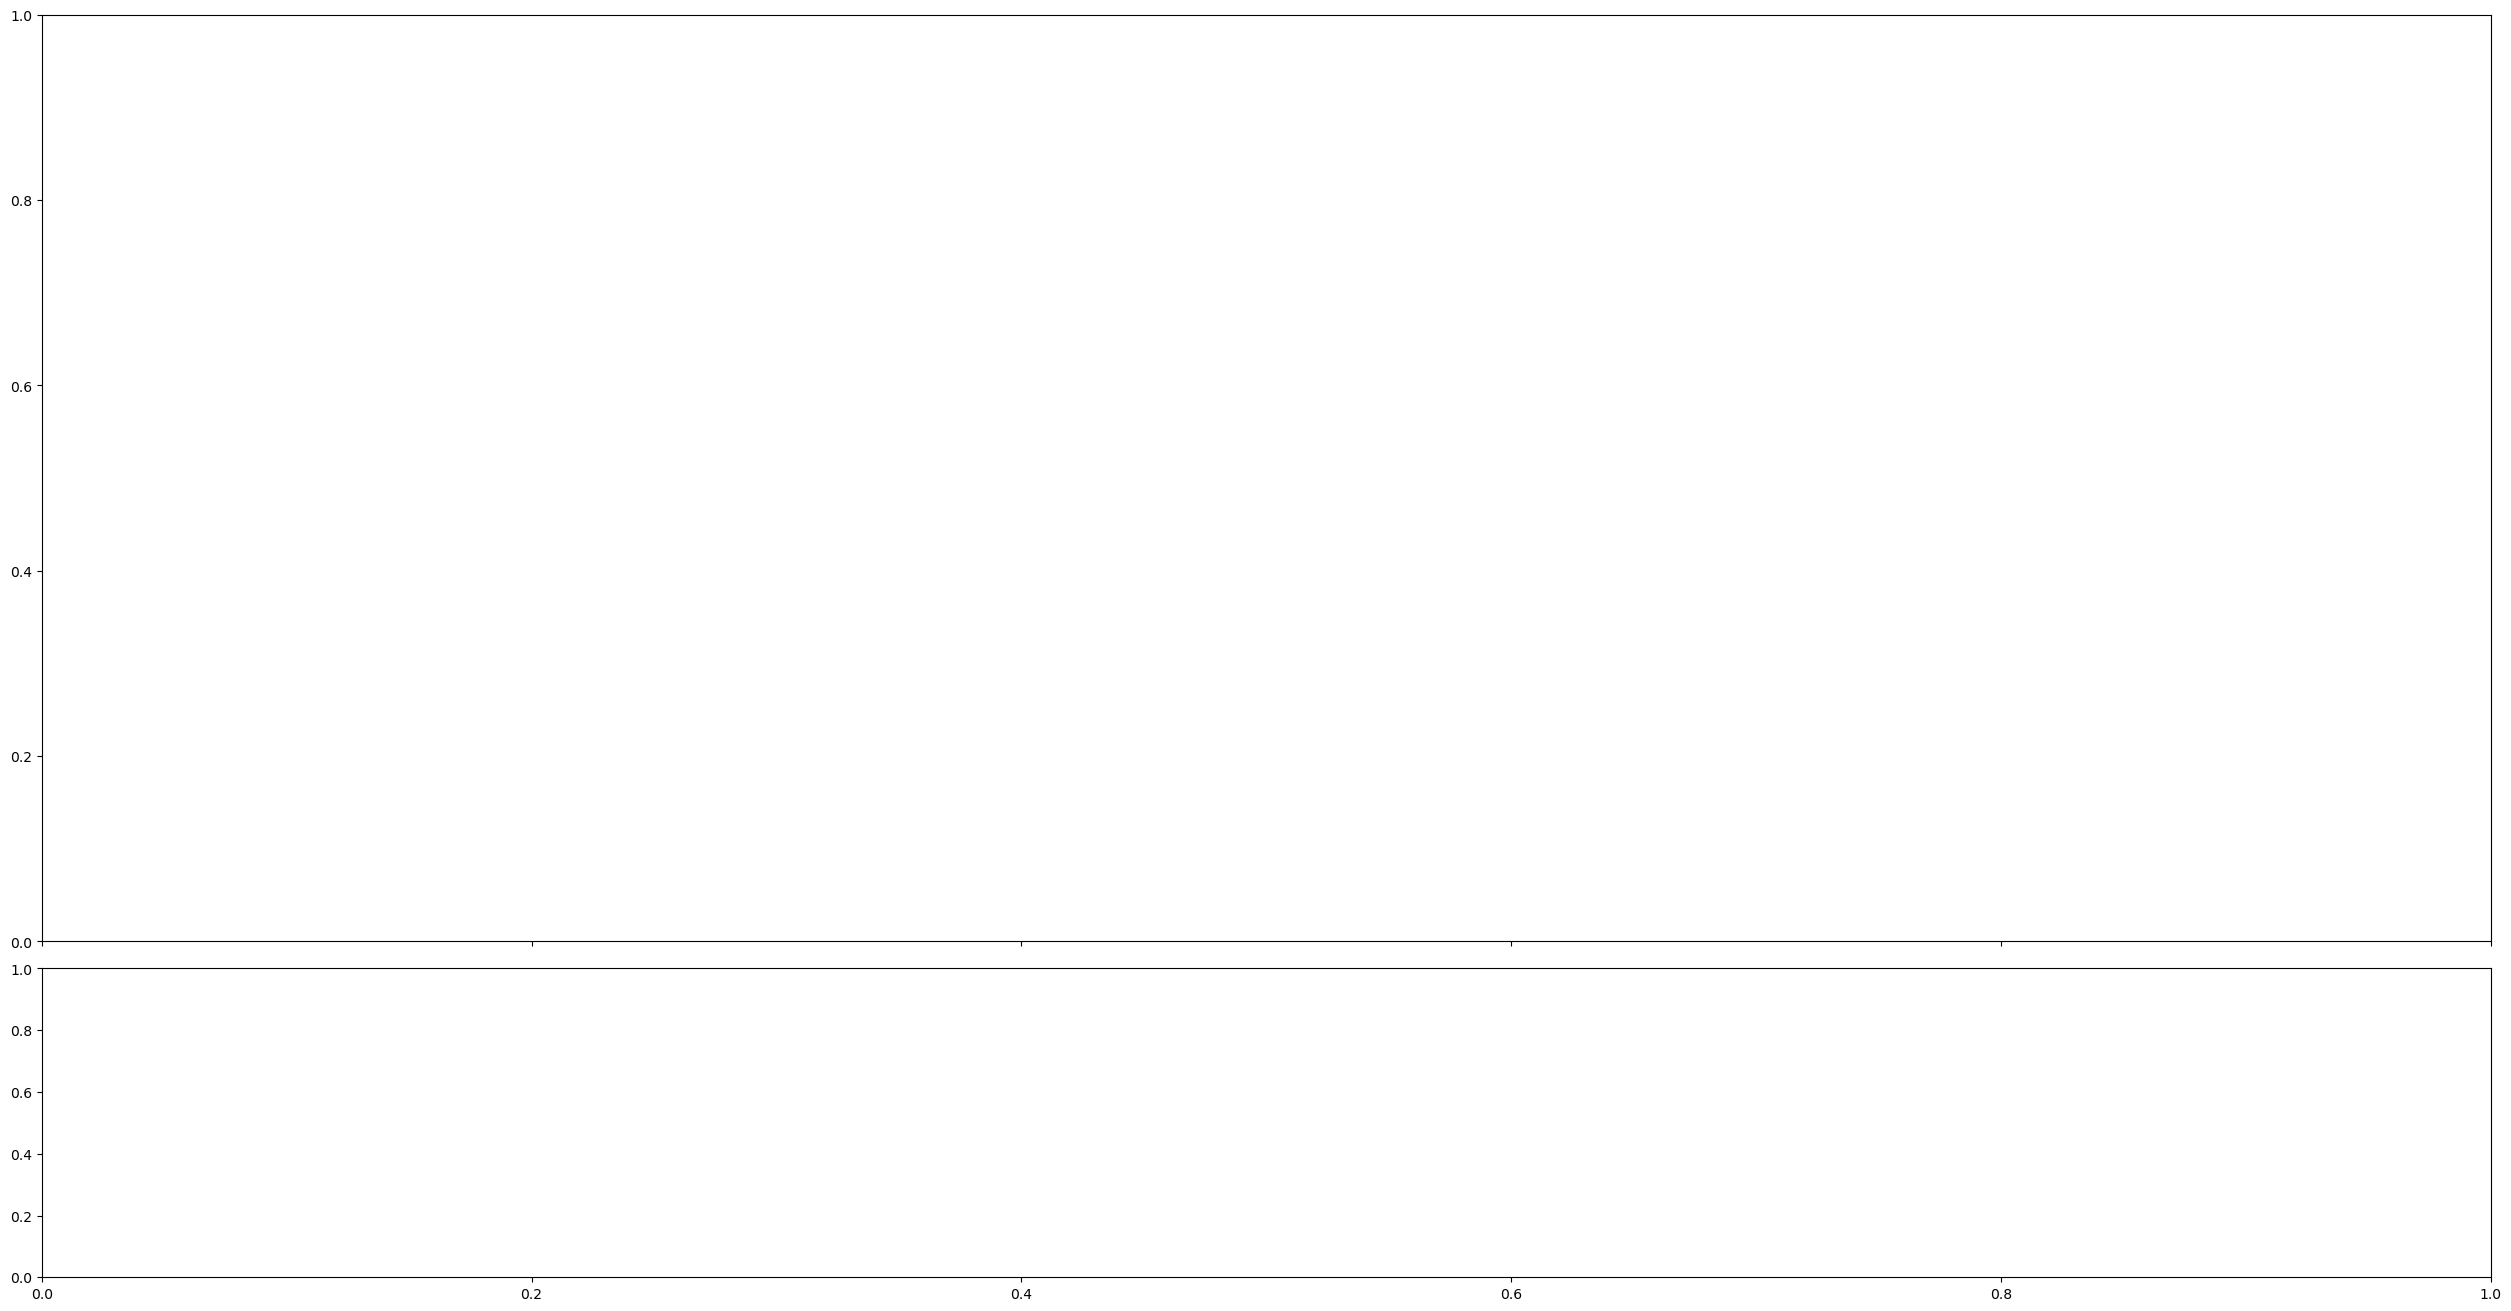

In [49]:
import matplotlib.pyplot as plt

time_slice = slice(230_000, 240_000)

fig, axes = plt.subplots(2, 1, figsize=(25, 13), sharex=True, constrained_layout=True, gridspec_kw={"height_ratios": [3, 1]},)

results.isel(time=time_slice).acausal_posterior.sum('state').plot(x='time', y='position', ax=axes[0], robust=True, cmap='bone_r')
axes[0].scatter(position_1d.iloc[time_slice].time,
                position_1d.iloc[time_slice].linear_position.values,
                s=1, color='magenta', zorder=10)

results.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])

In [91]:
from trajectory_analysis_tools import get_trajectory_data, get_ahead_behind_distance

trajectory_data = get_trajectory_data(
    results.sum('state').acausal_posterior,
    track_graph,
    classifier,
    linear_position_df[['projected_x_position', 'projected_y_position']],
    linear_position_df.track_segment_id,
    position_info.head_orientation,
)

ahead_behind_distance = get_ahead_behind_distance(
    track_graph, *trajectory_data)
mental_position_edges = trajectory_data[-1]
mental_position_edge_id = np.asarray(
    [track_graph.edges[edge]['edge_id'] for edge in mental_position_edges])

NameError: name 'position_info' is not defined

In [30]:
from ripple_detection import get_multiunit_population_firing_rate

SAMPLING_FREQUENCY = 500

multiunit_spikes = (np.any(~np.isnan(marks.values), axis=1)
                    ).astype(float)
multiunit_firing_rate = pd.DataFrame(
    get_multiunit_population_firing_rate(
        multiunit_spikes, SAMPLING_FREQUENCY), index=marks.time,
    columns=['firing_rate'])

In [31]:
from ripple_detection import multiunit_HSE_detector

multiunit_high_synchrony_times = multiunit_HSE_detector(
    marks.time.values,
    multiunit_spikes,
    position_info.head_speed.values,
    sampling_frequency=SAMPLING_FREQUENCY,
    minimum_duration=0.015,
    zscore_threshold=2.0,
    close_event_threshold=0.000)

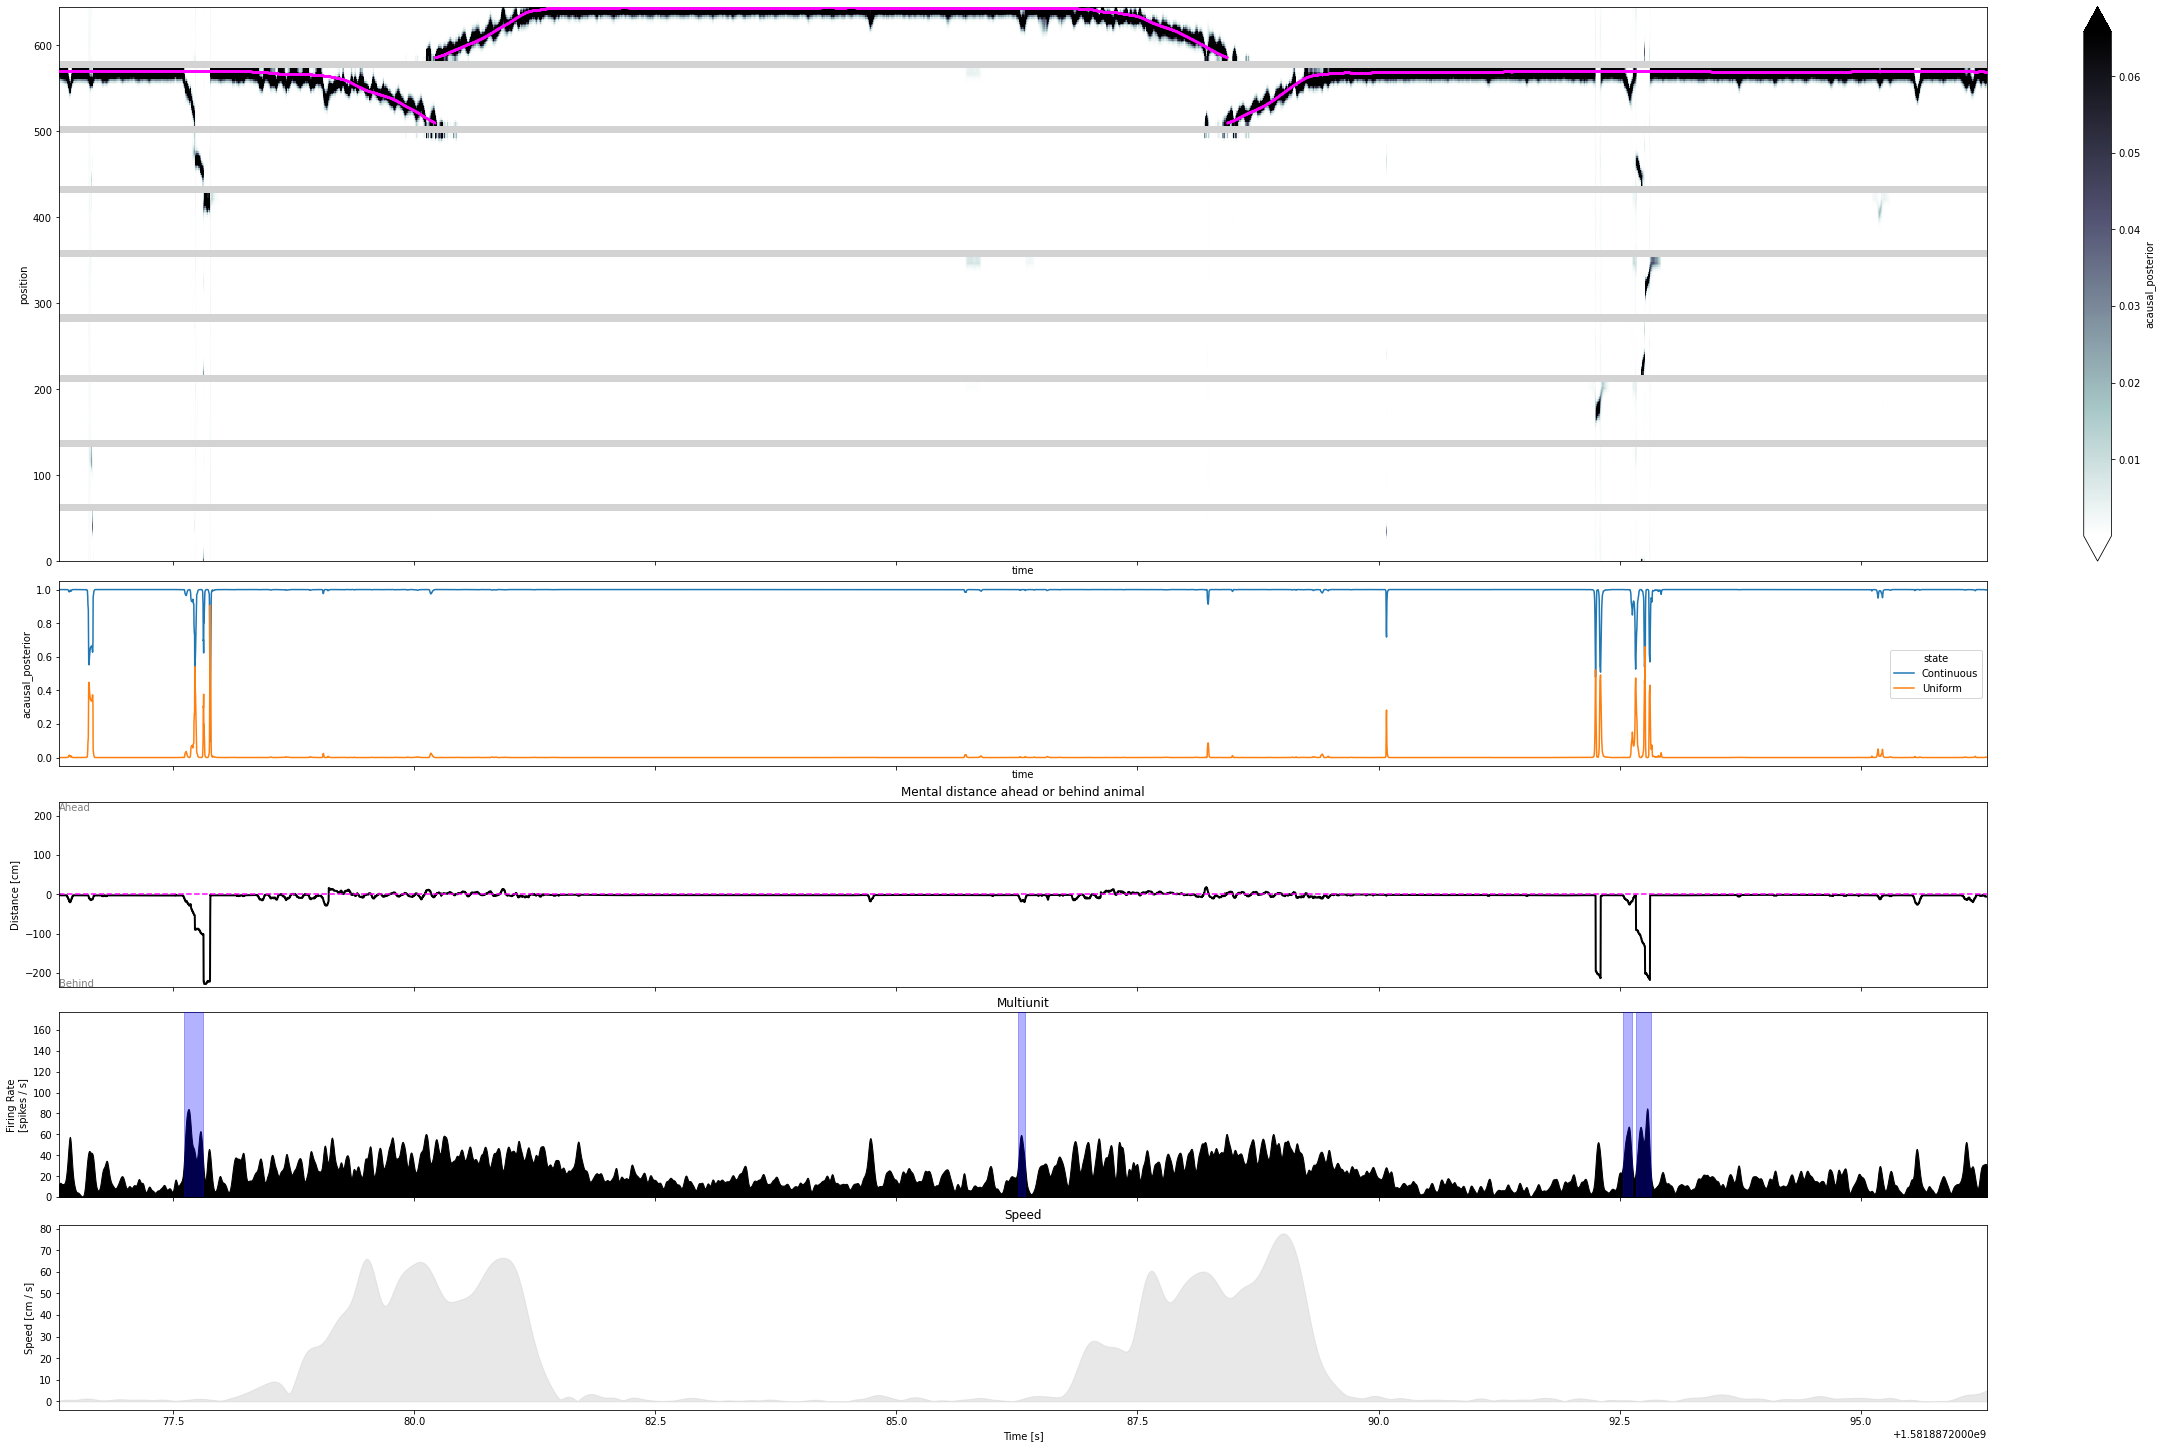

In [32]:
import matplotlib.pyplot as plt
import copy


def plot_classifier(
    time_slice,
    results,
    classifier,
    position_info,
    linear_position_df,
    ahead_behind_distance,
    multiunit_firing_rate,
    multiunit_high_synchrony_times,
    cmap='bone_r',
    figsize=(30, 20)
):

    cmap = copy.copy(plt.cm.get_cmap(cmap))
    cmap.set_bad(color="lightgrey", alpha=1.0)

    fig, axes = plt.subplots(5, 1, figsize=figsize, sharex=True, constrained_layout=True,
                             gridspec_kw={"height_ratios": [3, 1, 1, 1, 1]},)

    time = results.isel(time=time_slice).time
    (results
     .isel(time=time_slice)
     .acausal_posterior
     .sum('state')
     .where(classifier.environments[0].is_track_interior_)
     .plot(x='time', y='position', ax=axes[0], robust=True, cmap=cmap))
    axes[0].scatter(time,
                    linear_position_df.iloc[time_slice].linear_position.values,
                    s=1, color='magenta', zorder=10)

    results.isel(time=time_slice).acausal_posterior.sum('position').plot(x='time', hue='state', ax=axes[1])
    axes[2].plot(time,
                 ahead_behind_distance[time_slice],
                 color="black", linewidth=2)
    axes[2].axhline(0, color="magenta", linestyle="--")
    axes[2].set_title("Mental distance ahead or behind animal")
    axes[2].set_ylabel("Distance [cm]")
    max_dist = np.max(np.abs(ahead_behind_distance)) + 5
    axes[2].set_ylim((-max_dist, max_dist))
    axes[2].text(time[0], max_dist - 1, "Ahead", color="grey", va='top')
    axes[2].text(time[0], -max_dist + 1, "Behind", color="grey")

    # ax 3
    axes[3].fill_between(
        multiunit_firing_rate.iloc[time_slice].index.values,
        multiunit_firing_rate.iloc[time_slice].values.squeeze(),
        color="black",
    )
    axes[3].set_ylabel("Firing Rate\n[spikes / s]")
    axes[3].set_title("Multiunit")
    axes[3].set_ylim((0.0, np.max(np.asarray(multiunit_firing_rate))))


    cur_multiunit_HSE = interval_list_intersect(
        np.asarray(multiunit_high_synchrony_times),
        np.asarray([(time[0], time[-1])]))

    for start_time, end_time in cur_multiunit_HSE:
        axes[3].axvspan(start_time, end_time, color='blue', alpha=0.3, zorder=10)

    # ax 4
    axes[4].fill_between(
        time,
        position_info.iloc[time_slice]
        .head_speed.values.squeeze(),
        color="lightgrey",
        linewidth=1,
        alpha=0.5,
    )
    axes[4].set_title('Speed')
    axes[4].set_ylabel("Speed [cm / s]")
    axes[4].set_xlabel("Time [s]")
    

time_slice = slice(180_000, 190_000)
plot_classifier(time_slice, results, classifier, position_info, linear_position_df, ahead_behind_distance,
                multiunit_firing_rate, multiunit_high_synchrony_times)

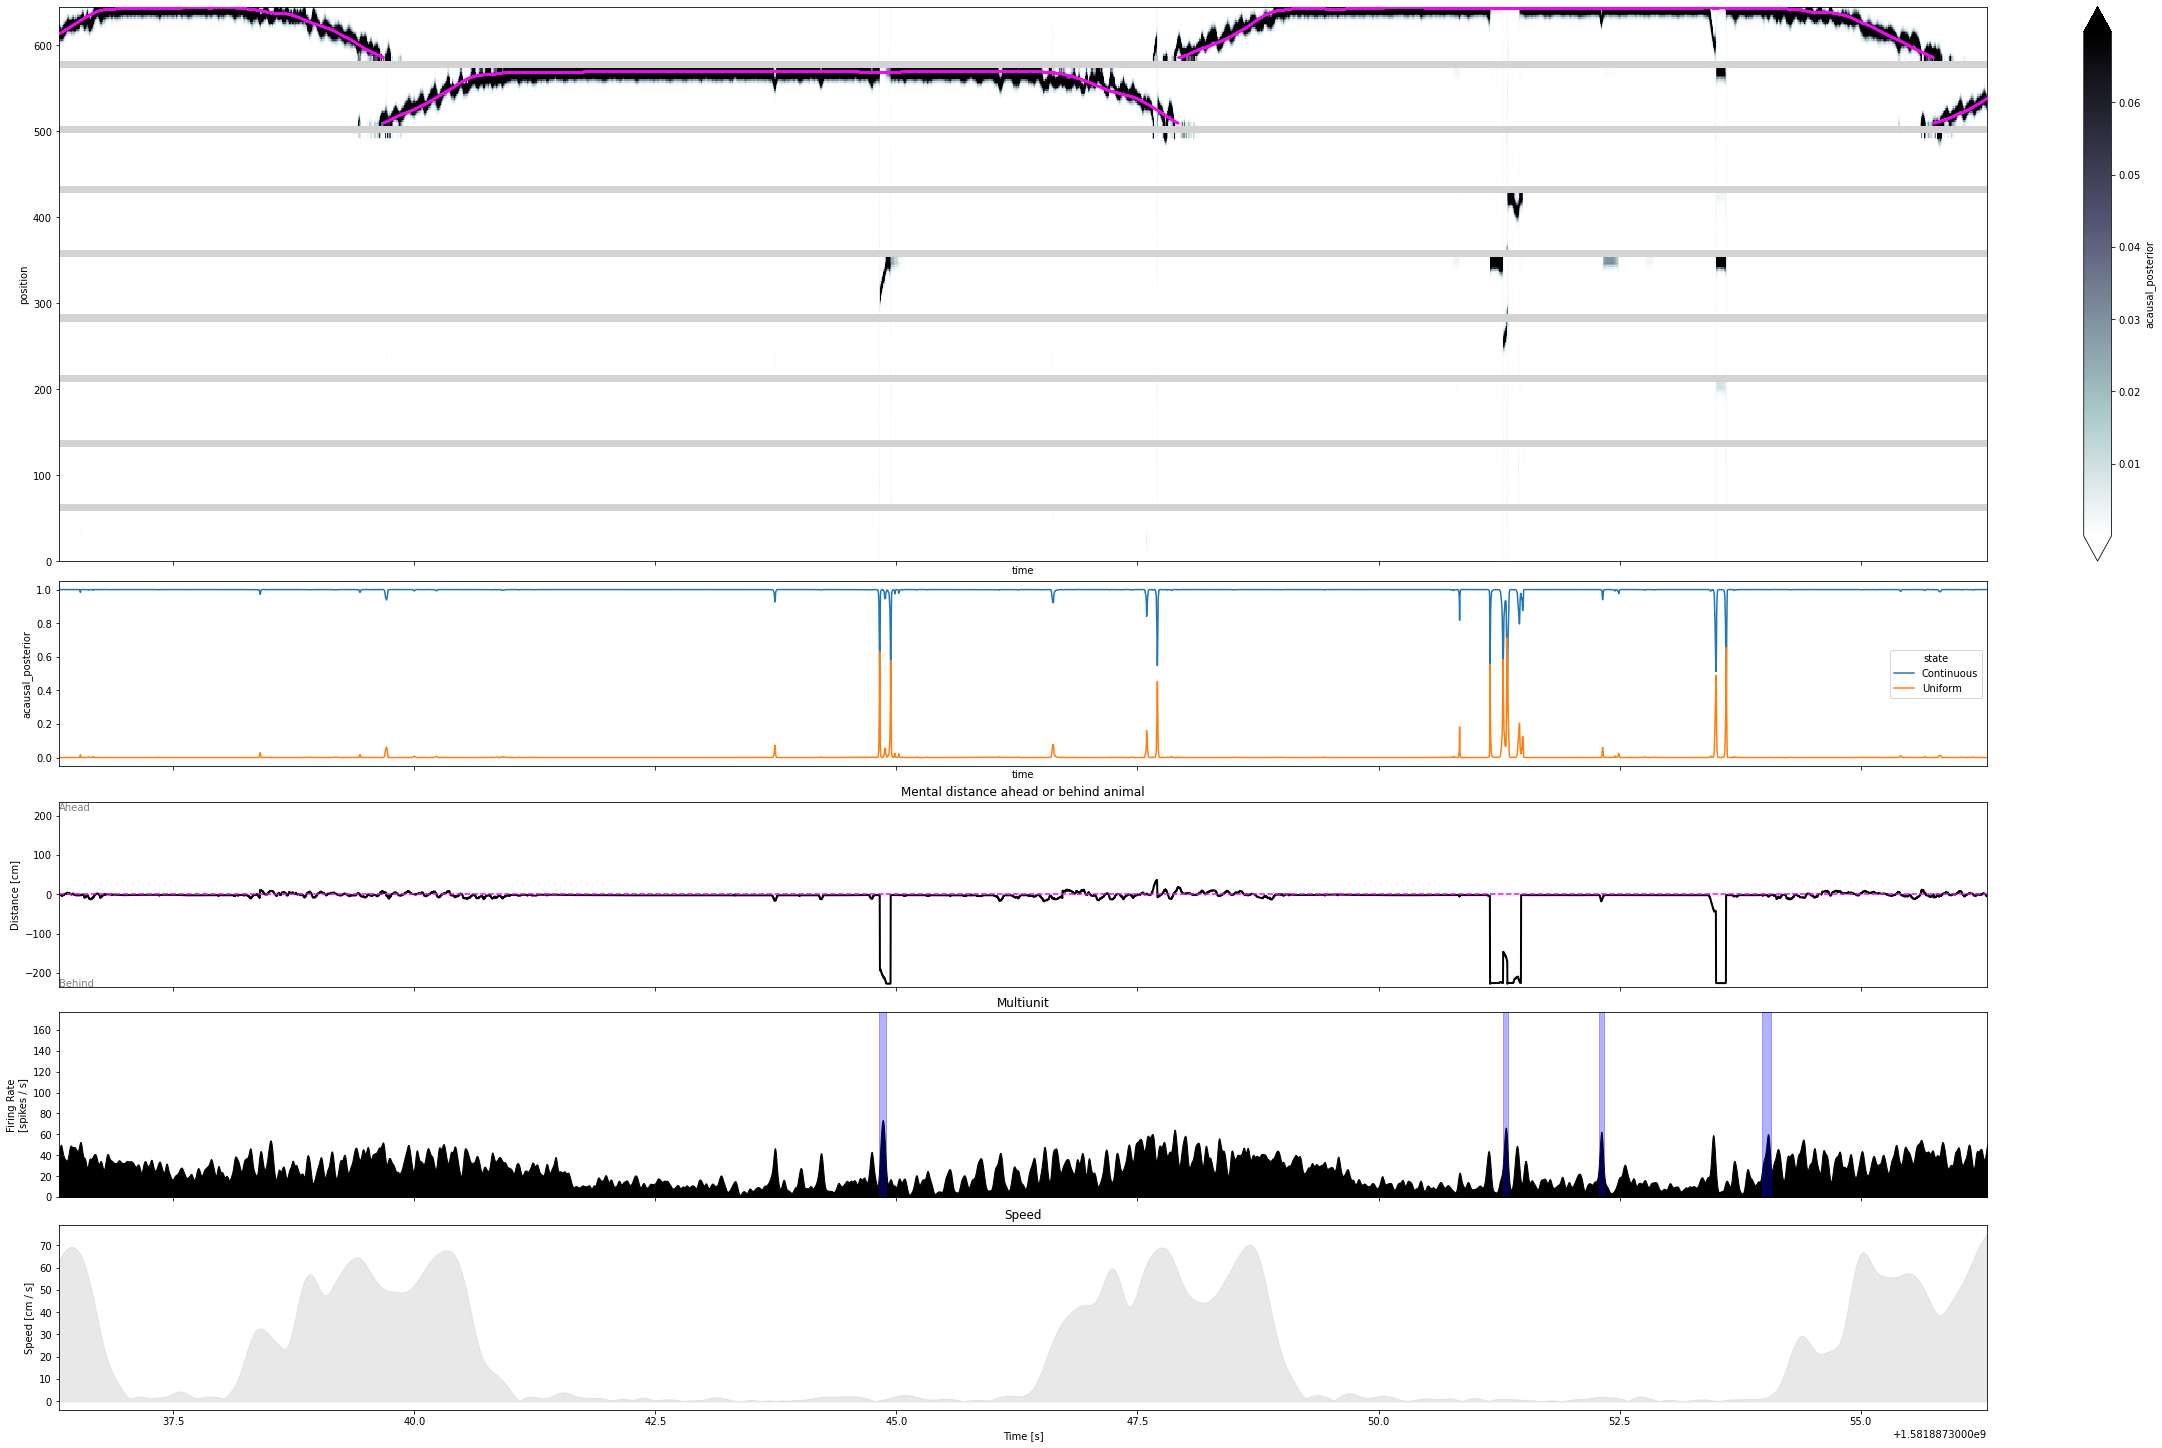

In [33]:
time_slice = slice(210_000, 220_000)
plot_classifier(time_slice, results, classifier, position_info, linear_position_df, ahead_behind_distance,
                multiunit_firing_rate, multiunit_high_synchrony_times)

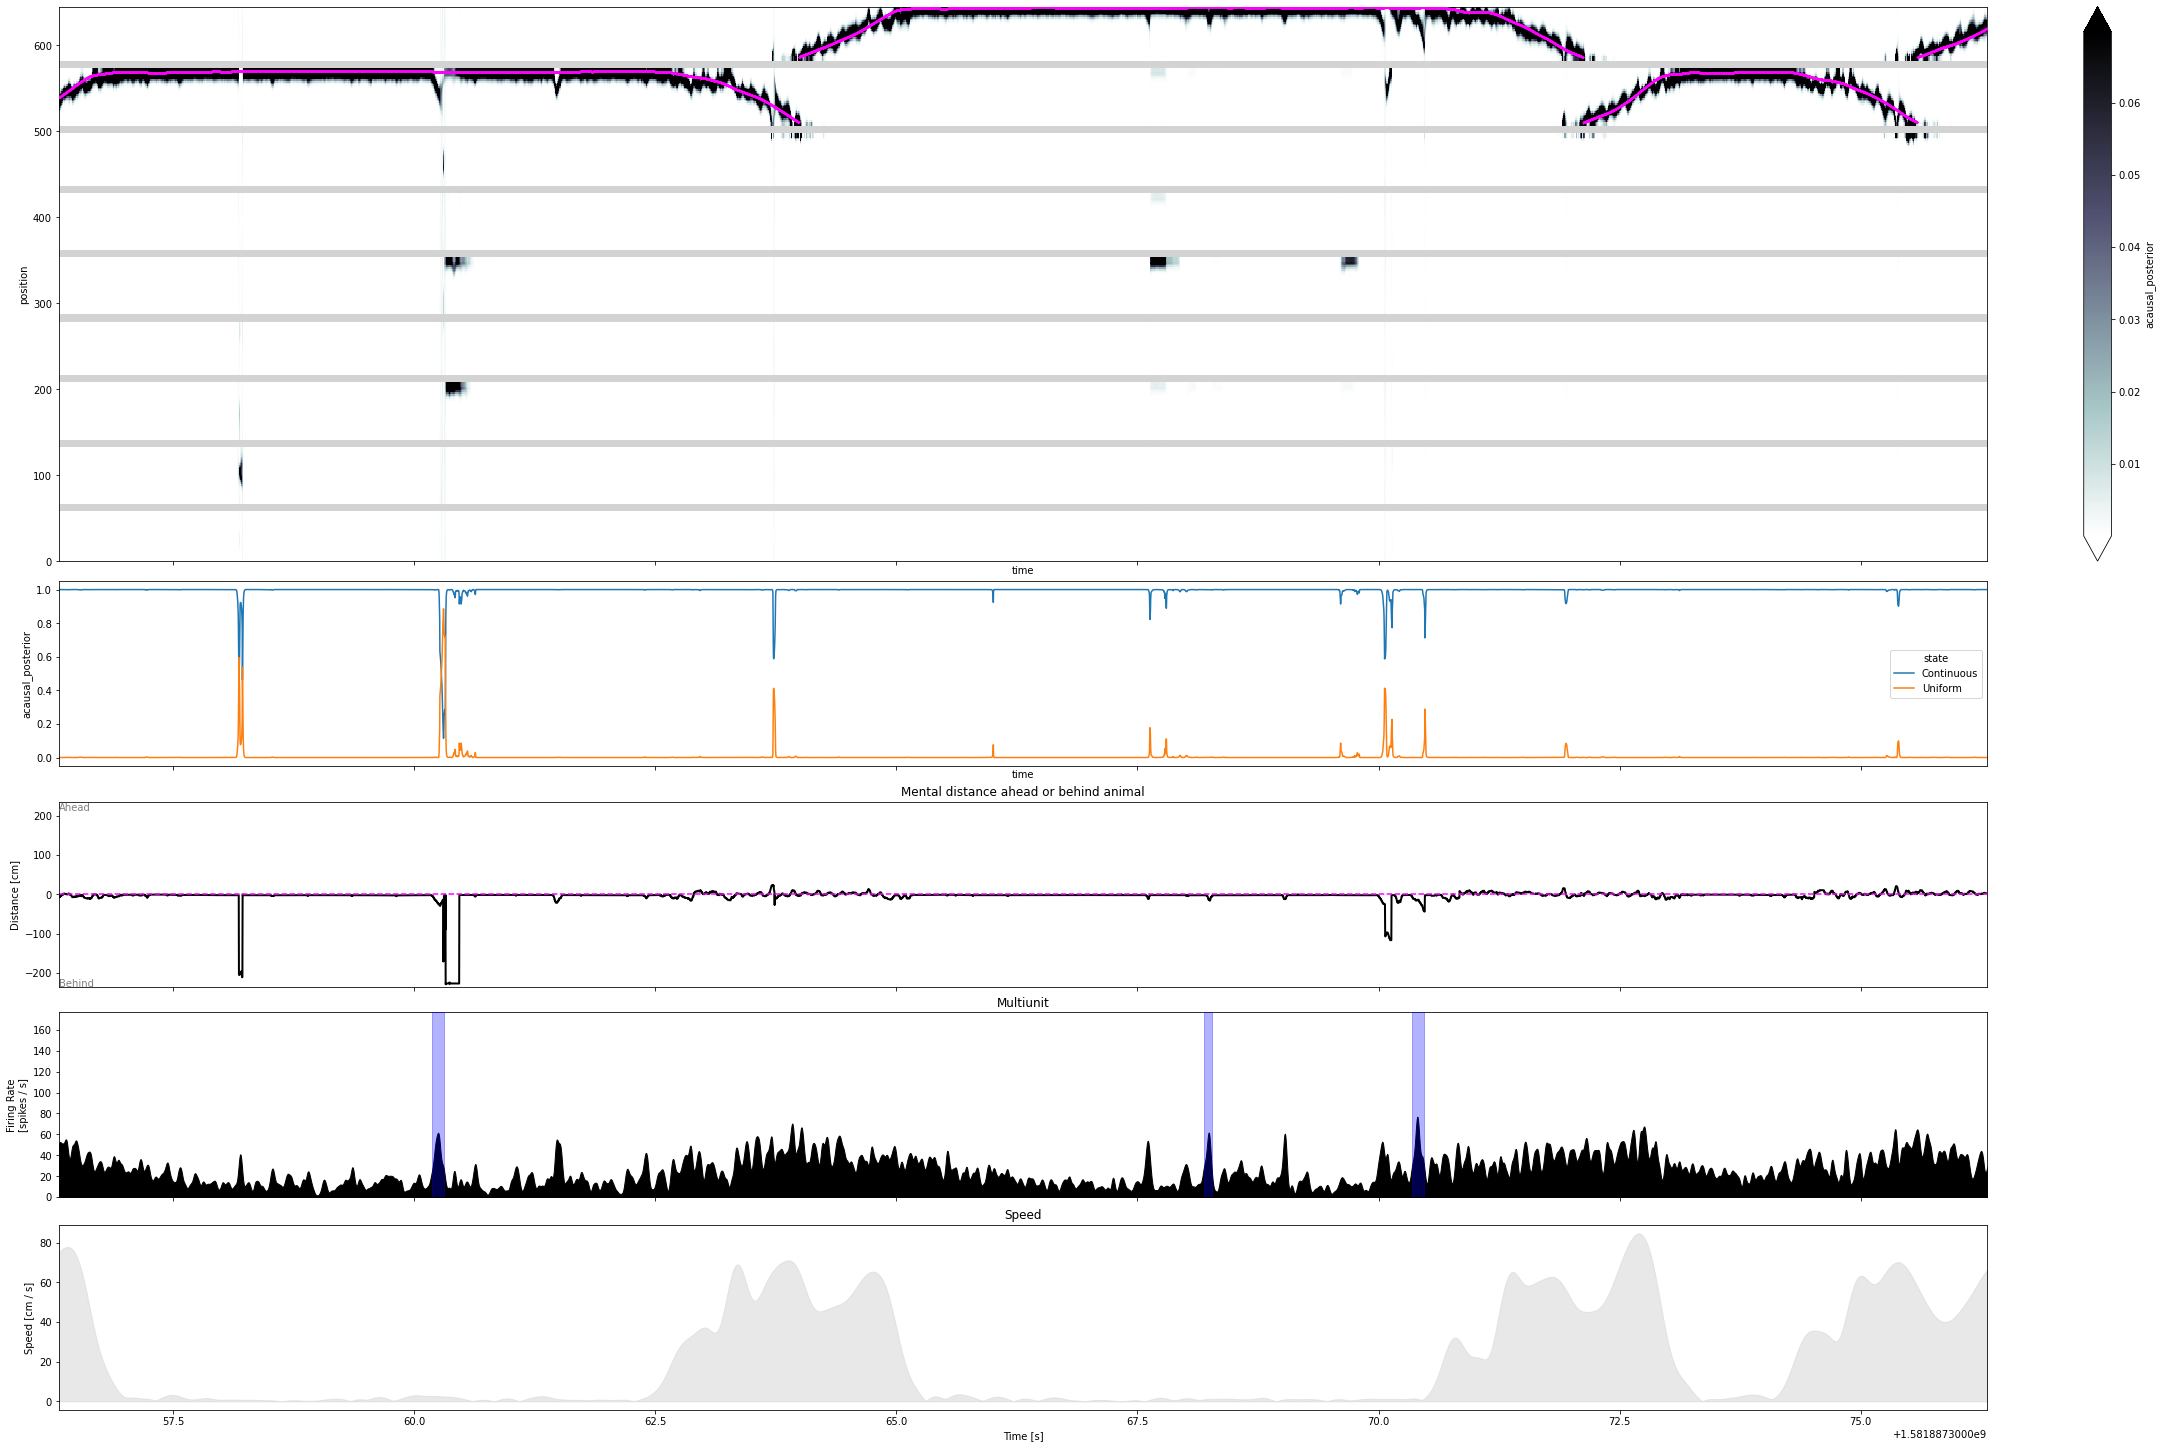

In [34]:
time_slice = slice(220_000, 230_000)
plot_classifier(time_slice, results, classifier, position_info, linear_position_df, ahead_behind_distance,
                multiunit_firing_rate, multiunit_high_synchrony_times)